In [1]:
import pandas as pd
import numpy as np

In [6]:
PATH = 'Dataset Client.xlsx'
df = pd.read_excel(PATH)

In [8]:
df.dropna(inplace = True)

In [7]:
# df.head()
df.info()
# df.columns
# df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315632 entries, 0 to 315631
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   SETTLEMENTDATE                210526 non-null  datetime64[ns]
 1   SA1_Price                     210526 non-null  float64       
 2   SA1_Demand                    210526 non-null  float64       
 3   AGLHAL_SA1_Natural Gas        210526 non-null  float64       
 4   ANGASTON_SA1_Diesel           210526 non-null  float64       
 5   CLEMGPWF_SA1_Wind             210526 non-null  float64       
 6   QUARANTN_SA1_Natural Gas      210526 non-null  float64       
 7   LONSDALE_SA1_Diesel           210526 non-null  float64       
 8   STANVAC_SA1_Diesel            210526 non-null  float64       
 9   HORNSDPR_SA1_Battery Storage  210527 non-null  object        
 10  BNGSF1_SA1_Solar              210526 non-null  float64       
 11  BARKIPS_SA1_N

In [9]:
df

,SETTLEMENTDATE,SA1_Price,SA1_Demand,AGLHAL_SA1_Natural Gas,ANGASTON_SA1_Diesel,CLEMGPWF_SA1_Wind,QUARANTN_SA1_Natural Gas,LONSDALE_SA1_Diesel,STANVAC_SA1_Diesel,HORNSDPR_SA1_Battery Storage,BNGSF1_SA1_Solar,BARKIPS_SA1_Natural Gas,ADP_SA1_Battery Storage,MAPS2_SA1_Solar,BOLIVAR_SA1_Battery Storage,CATHROCK_SA1_Wind,STARFHILL_SA1_Wind,HVWW_SA1_Solar
0,2022-07-01 00:04:59,379.96000,1654.10,0.0,36.0,44.60929,0.0,2.02342,0.0,0,0.0,111.05,0,0.0,0,2.961,13.59604,0.0
1,2022-07-01 00:09:59,365.35543,1621.37,0.0,0.0,48.52170,0.0,0.00000,0.0,0,0.0,79.59,0,0.0,0,5.017,16.69513,0.0
2,2022-07-01 00:14:59,374.62919,1642.13,0.0,0.0,48.17684,0.0,0.00000,0.0,0,0.0,52.03,0,0.0,0,6.045,16.39522,0.0
3,2022-07-01 00:19:59,379.53476,1619.22,0.0,0.0,48.06833,0.0,0.00000,0.0,0,0.0,22.77,0,0.0,0,4.573,16.29525,0.0
4,2022-07-01 00:24:59,369.74124,1633.80,0.0,0.0,43.18745,0.0,0.00000,0.0,0,0.0,9.00,0,0.0,0,3.379,14.09589,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210521,2024-06-30 23:39:59,219.44000,1637.47,0.0,0.0,21.14259,0.0,0.00000,0.0,0,0.0,103.00,0,0.0,0,3.400,2.79918,0.0
210522,2024-06-30 23:44:59,207.96774,1619.38,0.0,0.0,21.28501,0.0,0.00000,0.0,0,0.0,103.00,0,0.0,0,3.800,2.99912,0.0
210523,2024-06-30 23:49:59,175.98000,1592.39,0.0,0.0,20.47280,0.0,0.00000,0.0,0,0.0,103.00,0,0.0,0,2.700,2.09939,0.0
210524,2024-06-30 23:54:59,232.41000,1634.88,0.0,0.0,20.82757,0.0,0.00000,0.0,0,0.0,103.00,0,0.0,0,1.200,1.29962,0.0


### Part 1: Data Dictionary

`File-Level Properties`

- StructureWide format — one row per timestamp, one column per generator
- Temporal resolution5-minute intervals (NEM dispatch interval)
- Timestamp conventionInterval-ending (e.g., 00:04:59 = interval 00:00:00–00:04:59)
- RegionSA1 (South Australia)
- Total columns18 (1 timestamp + 1 price + 1 demand + 15 generators)

`Column-Level Dictionary`
- `SA1_Price ($/MWh)`: Wholesale spot price for SA1 region ~ The Pₜ in the DWP formula
- `SA1_Demand (MW)`: Operational demand in SA1 region enables demand-side analysis
- `Generator columns (15)` (MW) (instantaneous) or MWh (per interval) Dispatch output per 5-min interval 

Verify in full dataset: if values are MW, multiply by 5/60 to get MWh per interval (the Qₜˢ in the formula)

---
### Part 2: Data Cleaning

Issues found:
- 3 battery storage columns are `object` dtype (mixed int/float) — convert to numeric
- Negative prices (22.9% of intervals) and extreme spikes (>$5,000) — valid NEM market events, flag for analysis
- Set `SETTLEMENTDATE` as datetime index

In [10]:
# Battery storage columns are object dtype due to mixed int/float encoding
battery_cols = [
    'HORNSDPR_SA1_Battery Storage',
    'ADP_SA1_Battery Storage',
    'BOLIVAR_SA1_Battery Storage',
]
df[battery_cols] = df[battery_cols].apply(pd.to_numeric, errors='coerce')

# Set SETTLEMENTDATE as the index
df = df.set_index('SETTLEMENTDATE').sort_index()

# print('Dtypes after fix:')
# print(df.dtypes)
# print('\nRemaining NaNs from coerce:', df[battery_cols].isnull().sum().sum())

In [12]:
# # Flag negative and extreme prices
# # Both are valid NEM events but useful to isolate in analysis
df['price_negative'] = df['SA1_Price'] < 0       # renewable oversupply / demand response
df['price_spike']    = df['SA1_Price'] > 5000    # market cap / reliability events

print(f"Negative price intervals : {df['price_negative'].sum():,} ({df['price_negative'].mean():.1%})")
print(f"Price spike intervals    : {df['price_spike'].sum():,} ({df['price_spike'].mean():.3%})")

Negative price intervals : 48,234 (22.9%)
Price spike intervals    : 194 (0.092%)


In [13]:
# Identify the 15 generator columns (everything except price and demand)
gen_cols = [c for c in df.columns if c not in ['SA1_Price', 'SA1_Demand']]

# If SETTLEMENTDATE is already the index, reset it so melt can use it as id_var
df_wide = df.reset_index() if df.index.name == 'SETTLEMENTDATE' else df.copy()

# Melt wide → long: one row per (timestamp × generator)
df_long = df_wide.melt(
    id_vars=['SETTLEMENTDATE', 'SA1_Price', 'SA1_Demand'],
    value_vars=gen_cols,
    var_name='generator',
    value_name='dispatch_MW',
)

# Parse 'DUID_REGION_TECH' → three separate columns
# e.g. 'AGLHAL_SA1_Natural Gas' → DUID='AGLHAL', REGION='SA1', TECH='Natural Gas'
df_long[['DUID', 'REGION', 'TECH']] = (
    df_long['generator'].str.split('_', n=2, expand=True)
)
# df_long = df_long.drop(columns='generator')

# Reorder and sort
df_long = df_long[['SETTLEMENTDATE', 'DUID', 'REGION', 'TECH', 'dispatch_MW', 'SA1_Price', 'SA1_Demand']]
df_long = df_long.sort_values(['SETTLEMENTDATE', 'DUID']).reset_index(drop=True)

df_long.info()
df_long.TECH.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3578942 entries, 0 to 3578941
Data columns (total 7 columns):
 #   Column          Dtype         
---  ------          -----         
 0   SETTLEMENTDATE  datetime64[ns]
 1   DUID            object        
 2   REGION          object        
 3   TECH            object        
 4   dispatch_MW     object        
 5   SA1_Price       float64       
 6   SA1_Demand      float64       
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 191.1+ MB


TECH
Battery Storage    631578
Natural Gas        631578
Diesel             631578
Solar              631578
Wind               631578
Name: count, dtype: int64

---
### Part 3: Feature Engineering — Descriptive Analysis

`a. Parse Timestamps`

In [17]:
# Parse SETTLEMENTDATE to datetime and set as index on df_long
df_long['SETTLEMENTDATE'] = pd.to_datetime(df_long['SETTLEMENTDATE'])
df_long = df_long.set_index('SETTLEMENTDATE').sort_index()

# Extract time features from the datetime index
df_long['year']         = df_long.index.year
df_long['month']        = df_long.index.month
df_long['hour']         = df_long.index.hour
df_long['dayofweek']    = df_long.index.dayofweek  # 0 = Monday
df_long['is_weekend']   = df_long['dayofweek'] >= 5
df_long['quarter']      = df_long.index.quarter

# Southern Hemisphere seasons (South Australia)
season_map = {12: 'Summer', 1: 'Summer', 2: 'Summer',
              3: 'Autumn',  4: 'Autumn',  5: 'Autumn',
              6: 'Winter',  7: 'Winter',  8: 'Winter',
              9: 'Spring', 10: 'Spring', 11: 'Spring'}
df_long['season'] = df_long['month'].map(season_map)

# NEM peak period: 07:00-22:00 weekdays
df_long['is_peak'] = (~df_long['is_weekend']) & (df_long['hour'] >= 7) & (df_long['hour'] < 22)

# Financial year (NEM cycle: Jul-Jun)
df_long['financial_year'] = df_long.index.year.where(
    df_long.index.month >= 7, df_long.index.year - 1
)
# df_long[['DUID', 'TECH', 'dispatch_MWh', 'year', 'month', 'season', 'hour', 'is_peak', 'financial_year']].head(6)
df_long

,DUID,REGION,TECH,dispatch_MW,SA1_Price,SA1_Demand,dispatch_MWh,year,month,hour,dayofweek,is_weekend,quarter,season,is_peak,financial_year
SETTLEMENTDATE,,,,,,,,,,,,,,,,
2022-07-01 00:04:59,ADP,SA1,Battery Storage,0.0,379.96000,1654.10,0.0,2022,7,0,4,False,3,Winter,False,2022
2022-07-01 00:04:59,AGLHAL,SA1,Natural Gas,0.0,379.96000,1654.10,0.0,2022,7,0,4,False,3,Winter,False,2022
2022-07-01 00:04:59,ANGASTON,SA1,Diesel,36.0,379.96000,1654.10,3.0,2022,7,0,4,False,3,Winter,False,2022
2022-07-01 00:04:59,BARKIPS,SA1,Natural Gas,111.05,379.96000,1654.10,9.254167,2022,7,0,4,False,3,Winter,False,2022
2022-07-01 00:04:59,BNGSF1,SA1,Solar,0.0,379.96000,1654.10,0.0,2022,7,0,4,False,3,Winter,False,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-30 23:59:59,QUARANTN,SA1,Natural Gas,0.0,204.47554,1614.26,0.0,2024,6,23,6,True,2,Winter,False,2023
2024-06-30 23:59:59,STANVAC,SA1,Diesel,0.0,204.47554,1614.26,0.0,2024,6,23,6,True,2,Winter,False,2023
2024-06-30 23:59:59,STARFHILL,SA1,Wind,1.59953,204.47554,1614.26,0.133294,2024,6,23,6,True,2,Winter,False,2023


### Part 4: Qualitative analysis

### Convert dispatch MWh 

In [18]:
# Each dispatch interval = 5 minutes = 5/60 hours
# MW (instantaneous power) × interval duration (h) = MWh (energy delivered)
INTERVAL_H = 5 / 60

df_long['dispatch_MWh'] = df_long['dispatch_MW'] * INTERVAL_H # 1MW power sustained in one hour

# # Verification: per-tech totals across the full dataset
summary = (
    df_long.groupby('TECH')[['dispatch_MW', 'dispatch_MWh']]
    .agg(mean_MW=('dispatch_MW', 'mean'),
         total_GWh=('dispatch_MWh', lambda x: x.sum() / 1_000))
    .round(2)
    .sort_values('total_GWh', ascending=False)
)
# print(summary)
df_long[['DUID', 'TECH', 'dispatch_MW', 'dispatch_MWh']].head(6)

,DUID,TECH,dispatch_MW,dispatch_MWh
SETTLEMENTDATE,,,,
2022-07-01 00:04:59,ADP,Battery Storage,0.0,0.0
2022-07-01 00:04:59,AGLHAL,Natural Gas,0.0,0.0
2022-07-01 00:04:59,ANGASTON,Diesel,36.0,3.0
2022-07-01 00:04:59,BARKIPS,Natural Gas,111.05,9.254167
2022-07-01 00:04:59,BNGSF1,Solar,0.0,0.0
2022-07-01 00:04:59,BOLIVAR,Battery Storage,0.0,0.0


### Battery break down
- Negative value expected when charging, means:
 + when chargin battery and price is positive, Q_t <0 and P_t > 0
 -> generator paid for electricty
 + when chargin battery and price is negatice (demand < supply), both <0
 -> generator positively gains due to the surplus of electricity
- Battery revenue doesn't come from how many electricity can be generate -> come from charging status

In [19]:
df_long.head(5)

,DUID,REGION,TECH,dispatch_MW,SA1_Price,SA1_Demand,dispatch_MWh,year,month,hour,dayofweek,is_weekend,quarter,season,is_peak,financial_year
SETTLEMENTDATE,,,,,,,,,,,,,,,,
2022-07-01 00:04:59,ADP,SA1,Battery Storage,0.0,379.96,1654.1,0.0,2022,7,0,4,False,3,Winter,False,2022
2022-07-01 00:04:59,AGLHAL,SA1,Natural Gas,0.0,379.96,1654.1,0.0,2022,7,0,4,False,3,Winter,False,2022
2022-07-01 00:04:59,ANGASTON,SA1,Diesel,36.0,379.96,1654.1,3.0,2022,7,0,4,False,3,Winter,False,2022
2022-07-01 00:04:59,BARKIPS,SA1,Natural Gas,111.05,379.96,1654.1,9.254167,2022,7,0,4,False,3,Winter,False,2022
2022-07-01 00:04:59,BNGSF1,SA1,Solar,0.0,379.96,1654.1,0.0,2022,7,0,4,False,3,Winter,False,2022


### DWP per generator, technology, peak hour

In [20]:
# Dispatch-Weighted Price: DWP = sum(Price_t * Dispatch_MWh_t) / sum(Dispatch_MWh_t)
# Revenue: Revenue = sum(Price_t) * dispatch_MWh_t
# Segment: by tech itself, by hours, by season
# Compare revenue and capture price volatility

def calc_dwp(group_cols):
    return (
        df_long
        .assign(price_x_energy=df_long['SA1_Price'] * df_long['dispatch_MWh']) # revenue 
        .groupby(group_cols)
        .apply(lambda g: pd.Series({
            'DWP_$/MWh'   : g['price_x_energy'].sum() / g['dispatch_MWh'].sum()
                            if g['dispatch_MWh'].sum() > 0 else np.nan,
            'total_MWh'   : g['dispatch_MWh'].sum(),
            'total_revenue_$': g['price_x_energy'].sum(),
            'n_intervals' : len(g),
        }), include_groups=False)
        .reset_index()
        .sort_values('DWP_$/MWh', ascending=False)
        .round(2)
    )

# # Segment 1: per DUID + TECH (individual generator level, 15 rows)
dwp_duid = calc_dwp(['DUID', 'TECH'])
print('=== Segment 1: DWP per DUID + TECH ===')
print(dwp_duid.to_string(index=False))

# Segment 2: per TECH (5 categories: Natural Gas, Diesel, Wind, Solar, Battery Storage)
dwp_tech = calc_dwp(['TECH'])
print('\n=== Segment 2: DWP per TECH (5 categories) ===')
dwp_tech

# Segment 3: per TECH + peak hour (5 categories: Natural Gas, Diesel, Wind, Solar, Battery Storage)
dwp_peak = calc_dwp(['TECH','season'])
print('\n=== Segment 3: DWP per TECH (season) ===')
dwp_peak.sort_values('DWP_$/MWh')

=== Segment 1: DWP per DUID + TECH ===
     DUID            TECH  DWP_$/MWh  total_MWh  total_revenue_$  n_intervals
  STANVAC          Diesel    1046.04    8301.36       8683583.13     210526.0
 ANGASTON          Diesel     823.68    8450.69       6960629.30     210526.0
 LONSDALE          Diesel     804.55    5864.68       4718414.86     210526.0
   AGLHAL     Natural Gas     457.30  122686.98      56105111.09     210526.0
 HORNSDPR Battery Storage     407.53   52740.07      21492990.25     210526.0
  BOLIVAR Battery Storage     368.28    1152.36        424386.75     210526.0
      ADP Battery Storage     313.28    5560.59       1742006.29     210526.0
  BARKIPS     Natural Gas     261.94  572905.54     150067968.49     210526.0
 QUARANTN     Natural Gas     250.03  322635.13      80666861.56     210526.0
 CATHROCK            Wind      91.94  275094.41      25292295.65     210526.0
STARFHILL            Wind      84.91  145539.37      12358383.88     210526.0
 CLEMGPWF            Wind

,TECH,season,DWP_$/MWh,total_MWh,total_revenue_$,n_intervals
14,Solar,Summer,18.10,166255.65,3.008572e+06,156378.0
13,Solar,Spring,20.32,132922.42,2.700359e+06,157248.0
12,Solar,Autumn,50.78,129189.00,6.560655e+06,158976.0
18,Wind,Summer,53.05,203579.25,1.080059e+07,156378.0
17,Wind,Spring,66.07,191807.35,1.267287e+07,157248.0
16,Wind,Autumn,83.21,164062.58,1.365138e+07,158976.0
15,Solar,Winter,107.85,90712.58,9.783448e+06,158976.0
19,Wind,Winter,109.25,197054.14,2.152860e+07,158976.0
9,Natural Gas,Spring,201.31,216838.10,4.365139e+07,157248.0
8,Natural Gas,Autumn,218.40,266266.44,5.815231e+07,158976.0


### Market value with spot sale price and regional demand

### Import visualization library

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy import stats
import numpy as np

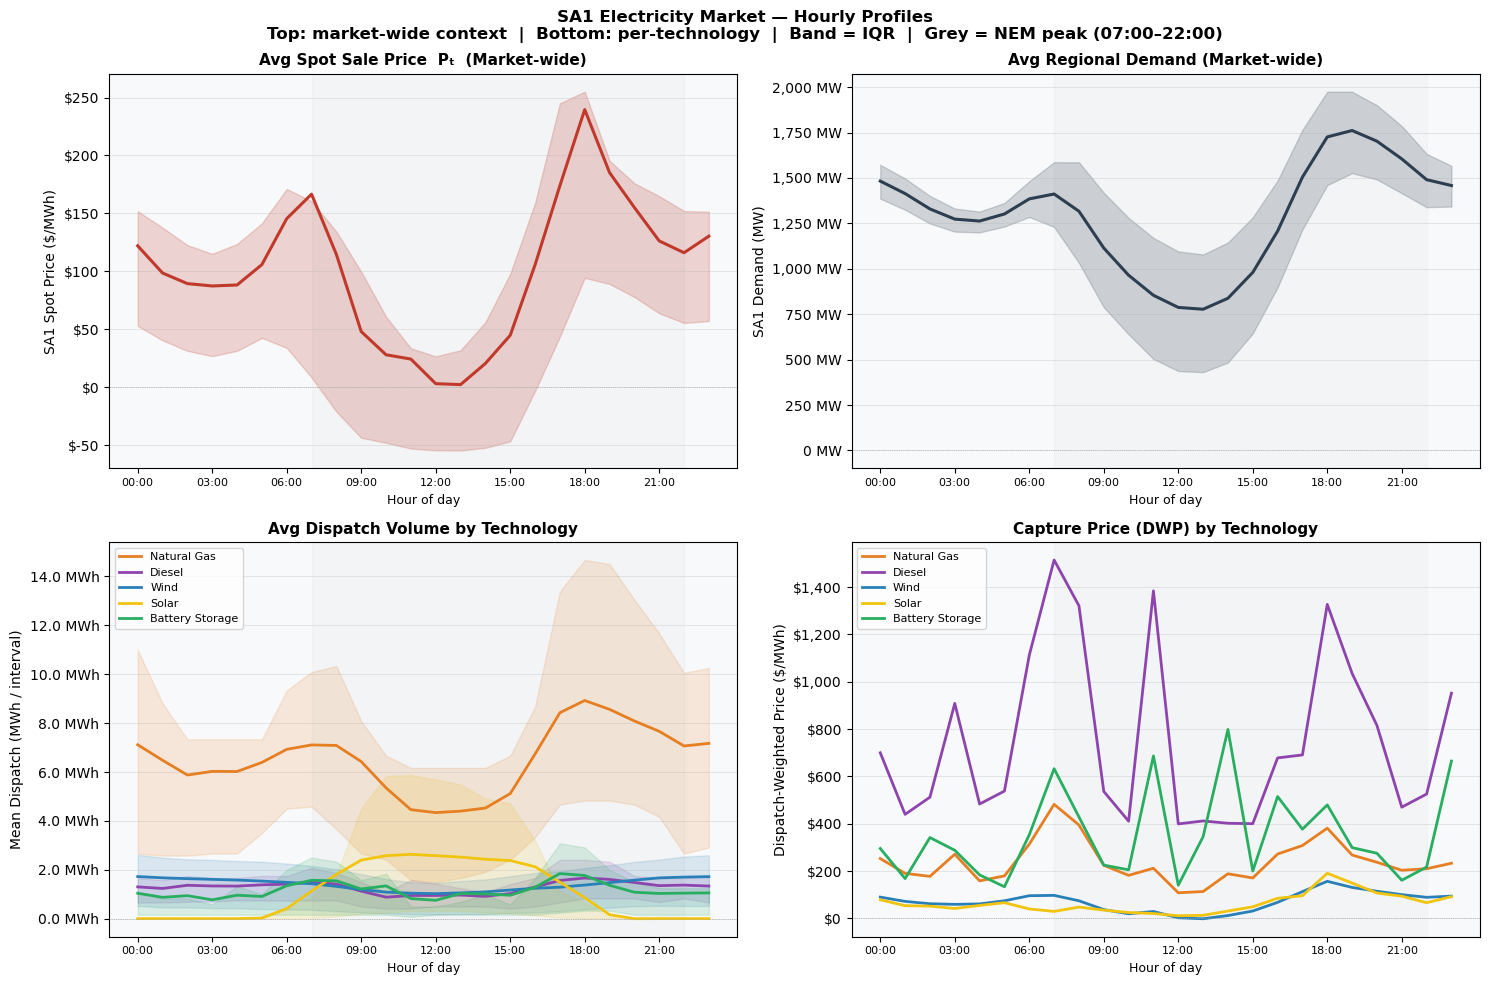

In [ ]:
TECHS  = ['Natural Gas', 'Diesel', 'Wind', 'Solar', 'Battery Storage']
COLORS = {'Natural Gas': '#e67e22', 'Diesel': '#8e44ad',
          'Wind': '#2980b9', 'Solar': '#f1c40f', 'Battery Storage': '#27ae60'}

active = df_long[df_long['dispatch_MWh'] > 0].copy()
active = active.assign(px_e=active['SA1_Price'] * active['dispatch_MWh'])

# --- Market-wide hourly stats (one row per 5-min interval, deduplicated by timestamp) ---
market = (
    df_long[~df_long.index.duplicated(keep='first')]
    [['SA1_Price', 'SA1_Demand', 'hour']]
)
mkt_stats = (
    market.groupby('hour')[['SA1_Price', 'SA1_Demand']]
    .agg(mean_price=('SA1_Price', 'mean'),
         p25_price =('SA1_Price', lambda x: x.quantile(0.25)),
         p75_price =('SA1_Price', lambda x: x.quantile(0.75)),
         mean_demand=('SA1_Demand', 'mean'),
         p25_demand =('SA1_Demand', lambda x: x.quantile(0.25)),
         p75_demand =('SA1_Demand', lambda x: x.quantile(0.75)))
    .reset_index()
)

# --- Per-tech hourly stats ---
dispatch_stats = (
    active.groupby(['TECH', 'hour'])['dispatch_MWh']
    .agg(mean='mean',
         p25=lambda x: x.quantile(0.25),
         p75=lambda x: x.quantile(0.75))
    .reset_index()
)
dwp_hourly = (
    active.groupby(['TECH', 'hour'])
    .apply(lambda g: g['px_e'].sum() / g['dispatch_MWh'].sum(), include_groups=False)
    .reset_index(name='DWP')
)

# --- 2×2 grid ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
(ax_price, ax_demand), (ax_dispatch, ax_dwp) = axes

hrs = mkt_stats['hour']

# Panel 1 — Average spot price
ax_price.fill_between(hrs, mkt_stats['p25_price'], mkt_stats['p75_price'],
                      alpha=0.2, color='#c0392b')
ax_price.plot(hrs, mkt_stats['mean_price'], color='#c0392b', linewidth=2.2)
ax_price.set_title('Avg Spot Sale Price  Pₜ  (Market-wide)', fontsize=11, fontweight='bold')
ax_price.set_ylabel('SA1 Spot Price ($/MWh)', fontsize=10)
ax_price.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Panel 2 — Average demand
ax_demand.fill_between(hrs, mkt_stats['p25_demand'], mkt_stats['p75_demand'],
                       alpha=0.2, color='#2c3e50')
ax_demand.plot(hrs, mkt_stats['mean_demand'], color='#2c3e50', linewidth=2.2)
ax_demand.set_title('Avg Regional Demand (Market-wide)', fontsize=11, fontweight='bold')
ax_demand.set_ylabel('SA1 Demand (MW)', fontsize=10)
ax_demand.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} MW'))

# Panel 3 — Dispatch by tech
for tech in TECHS:
    d = dispatch_stats[dispatch_stats['TECH'] == tech].sort_values('hour')
    ax_dispatch.fill_between(d['hour'], d['p25'], d['p75'], alpha=0.15, color=COLORS[tech])
    ax_dispatch.plot(d['hour'], d['mean'], color=COLORS[tech], linewidth=2, label=tech)
ax_dispatch.set_title('Avg Dispatch Volume by Technology', fontsize=11, fontweight='bold')
ax_dispatch.set_ylabel('Mean Dispatch (MWh / interval)', fontsize=10)
ax_dispatch.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f} MWh'))
ax_dispatch.legend(fontsize=8, loc='upper left')

# Panel 4 — Capture price (DWP) by tech
for tech in TECHS:
    w = dwp_hourly[dwp_hourly['TECH'] == tech].sort_values('hour')
    ax_dwp.plot(w['hour'], w['DWP'], color=COLORS[tech], linewidth=2, label=tech)
ax_dwp.set_title('Capture Price (DWP) by Technology', fontsize=11, fontweight='bold')
ax_dwp.set_ylabel('Dispatch-Weighted Price ($/MWh)', fontsize=10)
ax_dwp.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax_dwp.legend(fontsize=8, loc='upper left')

# Shared formatting
for ax in axes.flat:
    ax.axvspan(7, 22, alpha=0.04, color='grey')
    ax.axhline(0, color='#aaa', linewidth=0.6, linestyle=':')
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], fontsize=8)
    ax.set_xlabel('Hour of day', fontsize=9)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)
    ax.set_facecolor('#f8f9fa')

fig.suptitle(
    'SA1 Electricity Market — Hourly Profiles\n'
    'Top: market-wide context  |  Bottom: per-technology  |  Band = IQR  |  Grey = NEM peak (07:00–22:00)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

`Dispatch volumn by hour`
- Mean MWh per interval at each hour
- Solar spike at middat btw 7:00 - 18:00 and drop to zero for the rest of time,
- Diasel nearly zero or low except the rarely peak price bias

`Capture price by hour`
- capture by each hour per day
- Capture price for diasel, battery,and natural gas (more variable because different roles) always reach a peak at two single period of time whenever price meet the prevailing cap.

The gap between the two panels reveals the mismatch: Solar dispatches heavily at midday (left) but that's exactly when capture price is lowest (right) — the cannibalisation effect visible in one glance


### Variability of capture price within each technology

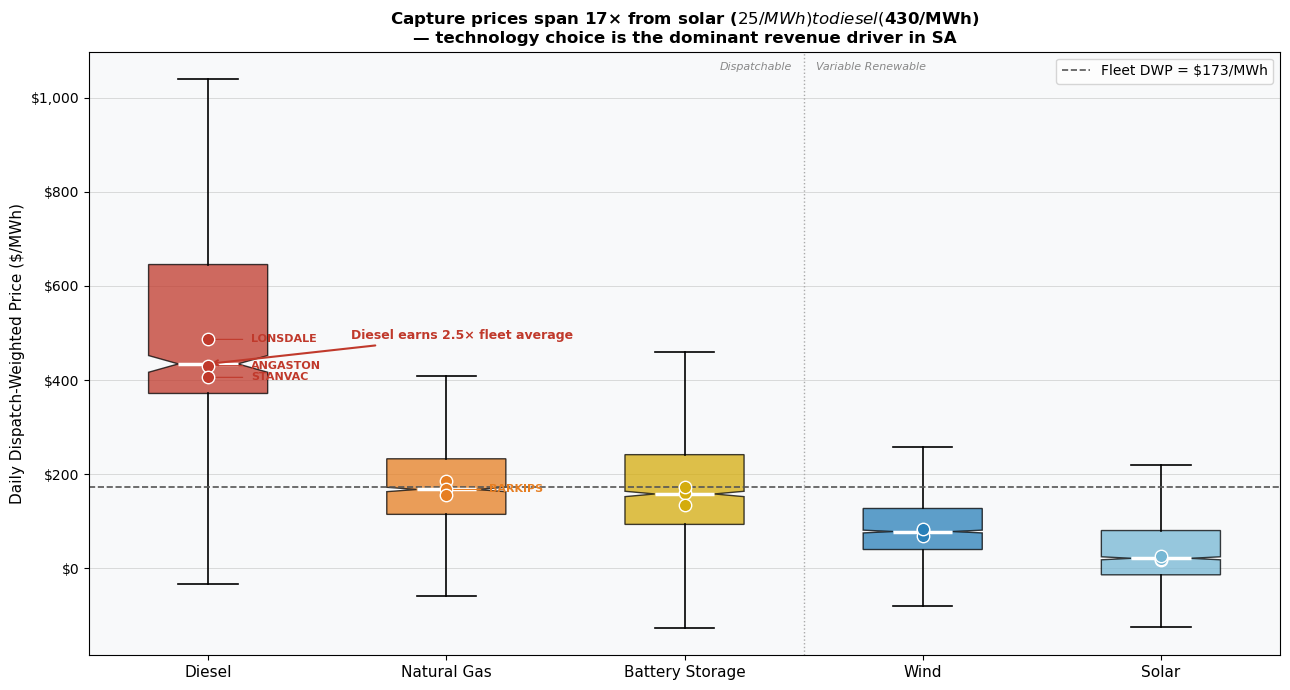

In [23]:
active = df_long[df_long['dispatch_MWh'] > 0].copy()
active['date'] = active.index.date

g = active.assign(px_e=active['SA1_Price'] * active['dispatch_MWh']).groupby(['DUID', 'TECH', 'date'])
daily_dwp = (g['px_e'].sum() / g['dispatch_MWh'].sum()).reset_index(name='DWP')

# Economic-role colour palette:
# Dispatchable (can choose when to run) → warm tones
# Variable renewable (run when resource available) → cool tones
COLORS = {
    'Diesel'          : '#c0392b',  # deep red   — dispatchable, highest premium
    'Natural Gas'     : '#e67e22',  # amber      — dispatchable, mid-tier
    'Battery Storage' : '#d4ac0d',  # gold       — dispatchable, arbitrage
    'Wind'            : '#2980b9',  # blue       — variable renewable
    'Solar'           : '#76b7d4',  # light blue — variable renewable, lowest capture
}

tech_order = (
    daily_dwp.groupby('TECH')['DWP'].median()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(13, 7))

# Box plot
bp = ax.boxplot(
    [daily_dwp[daily_dwp['TECH'] == t]['DWP'].values for t in tech_order],
    patch_artist=True,
    notch=True,
    showfliers=False,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, tech in zip(bp['boxes'], tech_order):
    patch.set_facecolor(COLORS[tech])
    patch.set_alpha(0.75)

# Per-DUID median dots — labelled for outliers
LABEL_DUIDS = {'BARKIPS', 'ANGASTON', 'LONSDALE', 'STANVAC'}  # outliers to label
for j, tech in enumerate(tech_order, start=1):
    duid_medians = daily_dwp[daily_dwp['TECH'] == tech].groupby('DUID')['DWP'].median()
    for duid, val in duid_medians.items():
        ax.scatter(j, val, color=COLORS[tech], edgecolors='white',
                   s=80, zorder=5, linewidths=1.0)
        if duid in LABEL_DUIDS:
            ax.annotate(
                duid,
                xy=(j, val), xytext=(j + 0.18, val),
                fontsize=8, color=COLORS[tech], fontweight='bold',
                va='center',
                arrowprops=dict(arrowstyle='-', color=COLORS[tech],
                                lw=0.8, shrinkA=4, shrinkB=2),
            )

# Fleet DWP reference
vwap = (active['SA1_Price'] * active['dispatch_MWh']).sum() / active['dispatch_MWh'].sum()
ax.axhline(vwap, color='#555', linewidth=1.2, linestyle='--',
           label=f'Fleet DWP = ${vwap:.0f}/MWh')

# Annotation arrow: diesel median vs fleet average
diesel_idx    = tech_order.index('Diesel') + 1
diesel_median = daily_dwp[daily_dwp['TECH'] == 'Diesel']['DWP'].median()
ax.annotate(
    f'Diesel earns 2.5× fleet average',
    xy=(diesel_idx, diesel_median),
    xytext=(diesel_idx + 0.6, diesel_median * 1.12),
    fontsize=9, color='#c0392b', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
)

# Dispatchable / variable renewable role divider
dispatchable = ['Diesel', 'Natural Gas', 'Battery Storage']
variable     = ['Wind', 'Solar']
disp_positions = [tech_order.index(t) + 1 for t in dispatchable if t in tech_order]
var_positions  = [tech_order.index(t) + 1 for t in variable  if t in tech_order]
if disp_positions and var_positions:
    split_x = (max(disp_positions) + min(var_positions)) / 2
    ax.axvline(split_x, color='#aaa', linewidth=1, linestyle=':')
    ax.text(split_x - 0.05, ax.get_ylim()[1] * 0.98, 'Dispatchable',
            ha='right', va='top', fontsize=8, color='#888', fontstyle='italic')
    ax.text(split_x + 0.05, ax.get_ylim()[1] * 0.98, 'Variable Renewable',
            ha='left',  va='top', fontsize=8, color='#888', fontstyle='italic')

ax.set_xticks(range(1, len(tech_order) + 1))
ax.set_xticklabels(tech_order, fontsize=11)
ax.set_ylabel('Daily Dispatch-Weighted Price ($/MWh)', fontsize=11)
ax.set_title(
    'Capture prices span 17× from solar ($25/MWh) to diesel ($430/MWh)\n'
    '— technology choice is the dominant revenue driver in SA',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()

/var/folders/fs/vpv7t9012wxdx__nwt82lmpm0000gn/T/ipykernel_57461/2229603469.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  px_e_wide = daily_tech.pivot(index='date', columns='TECH', values='px_e_sum').fillna(0)
/var/folders/fs/vpv7t9012wxdx__nwt82lmpm0000gn/T/ipykernel_57461/2229603469.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mwh_wide  = daily_tech.pivot(index='date', columns='TECH', values='mwh_sum').fillna(0)


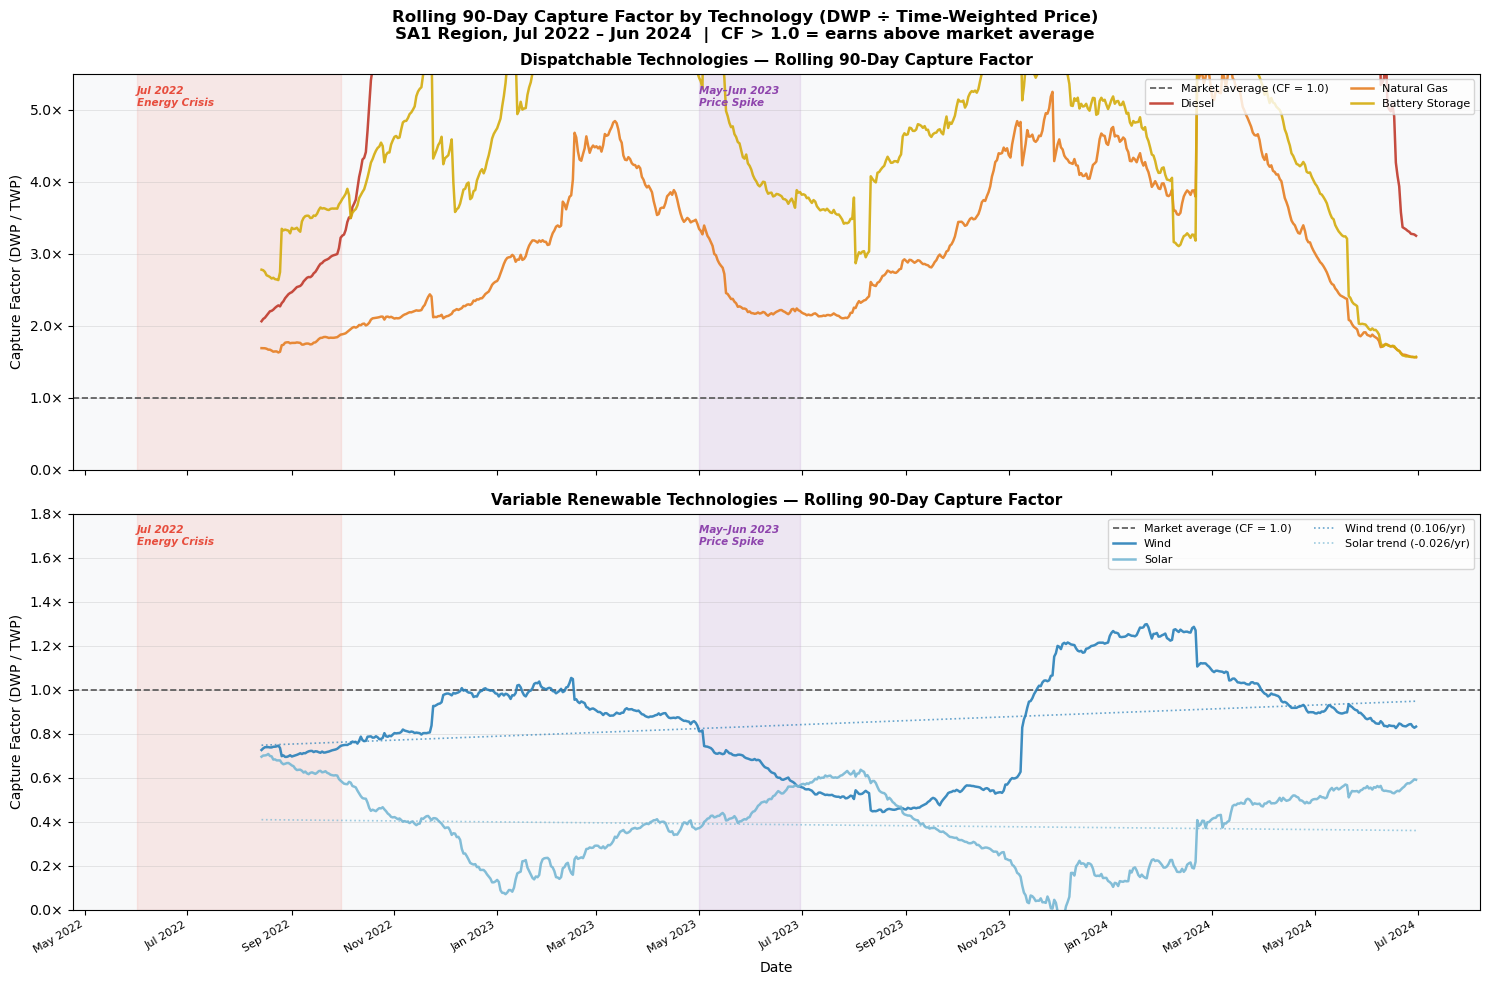

In [26]:
# ── Build daily inputs ────────────────────────────────────────────────
active = df_long[df_long['dispatch_MWh'] > 0].copy()
active['date'] = active.index.date

# Per-TECH daily: numerator (Price × MWh) and denominator (MWh)
daily_tech = (
    active.assign(px_e=active['SA1_Price'] * active['dispatch_MWh'])
    .groupby(['date', 'TECH'])
    .agg(px_e_sum=('px_e', 'sum'), mwh_sum=('dispatch_MWh', 'sum'))
    .reset_index()
)
px_e_wide = daily_tech.pivot(index='date', columns='TECH', values='px_e_sum').fillna(0)
mwh_wide  = daily_tech.pivot(index='date', columns='TECH', values='mwh_sum').fillna(0)
px_e_wide.index = pd.to_datetime(px_e_wide.index)
mwh_wide.index  = pd.to_datetime(mwh_wide.index)

# Market time-weighted price: simple mean of SA1_Price per day
market = df_long[~df_long.index.duplicated(keep='first')][['SA1_Price']].copy()
market['date'] = market.index.date
daily_mkt = market.groupby('date')['SA1_Price'].agg(price_sum='sum', n='count')
daily_mkt.index = pd.to_datetime(daily_mkt.index)

# ── Rolling 90-day capture factor = DWP / TWP ─────────────────────────
WINDOW = 90
roll_dwp = (px_e_wide.rolling(WINDOW, min_periods=45).sum()
            / mwh_wide.rolling(WINDOW, min_periods=45).sum().replace(0, np.nan))
roll_twp = (daily_mkt['price_sum'].rolling(WINDOW, min_periods=45).sum()
            / daily_mkt['n'].rolling(WINDOW, min_periods=45).sum())
cf = roll_dwp.div(roll_twp, axis=0)    # capture factor: 1.0 = market average

# ── Colour palette (same economic-role grouping as box plot) ──────────
COLORS = {
    'Diesel'          : '#c0392b',
    'Natural Gas'     : '#e67e22',
    'Battery Storage' : '#d4ac0d',
    'Wind'            : '#2980b9',
    'Solar'           : '#76b7d4',
}
DISP = ['Diesel', 'Natural Gas', 'Battery Storage']
VRE  = ['Wind', 'Solar']

# ── Event markers ─────────────────────────────────────────────────────
EVENTS = [
    ('2022-06-01', '2022-09-30', '#e74c3c', 'Jul 2022\nEnergy Crisis'),
    ('2023-05-01', '2023-06-30', '#8e44ad', 'May–Jun 2023\nPrice Spike'),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

def plot_panel(ax, techs, ylim, title):
    # Reference line
    ax.axhline(1.0, color='#555', linewidth=1.2, linestyle='--',
               label='Market average (CF = 1.0)', zorder=2)

    for tech in techs:
        if tech not in cf.columns:
            continue
        series = cf[tech].dropna()
        ax.plot(series.index, series, color=COLORS[tech],
                linewidth=1.8, label=tech, alpha=0.9)

    # Linear regression trend for VRE only
    if set(techs) & {'Wind', 'Solar'}:
        for tech in [t for t in ['Wind', 'Solar'] if t in techs and t in cf.columns]:
            s = cf[tech].dropna()
            x = np.arange(len(s))
            slope, intercept, *_ = stats.linregress(x, s.values)
            trend = slope * x + intercept
            ax.plot(s.index, trend, color=COLORS[tech], linewidth=1.2,
                    linestyle=':', alpha=0.7,
                    label=f'{tech} trend ({slope*365:.3f}/yr)')

    # Event shading + labels
    for start, end, color, label in EVENTS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color=color, alpha=0.10, zorder=0)
        ax.text(pd.Timestamp(start), ylim[1] * 0.97, label,
                fontsize=7.5, color=color, va='top', ha='left',
                fontstyle='italic', fontweight='bold')

    ax.set_ylim(*ylim)
    ax.set_ylabel('Capture Factor (DWP / TWP)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}×'))
    ax.legend(fontsize=8, loc='upper right', ncol=2)
    ax.set_facecolor('#f8f9fa')
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)

plot_panel(ax1, DISP, (0.0, 5.5),
           'Dispatchable Technologies — Rolling 90-Day Capture Factor')
plot_panel(ax2, VRE,  (0.0, 1.8),
           'Variable Renewable Technologies — Rolling 90-Day Capture Factor')

# Shared x-axis
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
ax2.set_xlabel('Date', fontsize=10)

fig.suptitle(
    'Rolling 90-Day Capture Factor by Technology (DWP ÷ Time-Weighted Price)\n'
    'SA1 Region, Jul 2022 – Jun 2024  |  CF > 1.0 = earns above market average',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

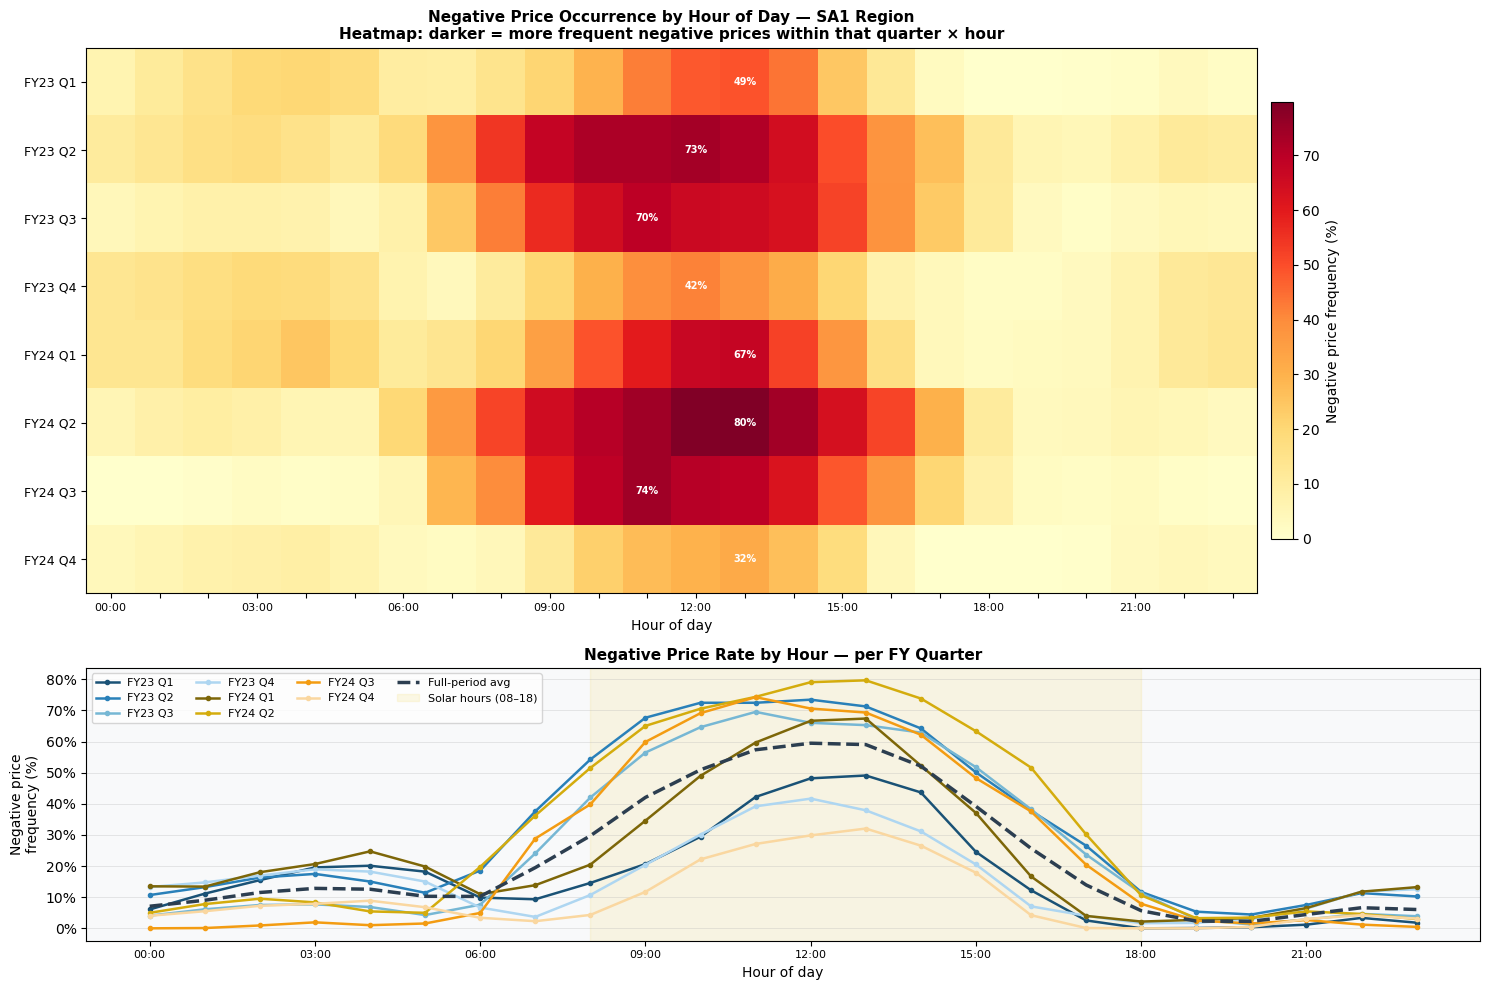

--- Negative price events per quarter ---
         count   rate
quarter              
FY23 Q1   4457  16.8%
FY23 Q2   8623  32.5%
FY23 Q3   6863  26.5%
FY23 Q4   4230  16.1%
FY24 Q1   6431  24.3%
FY24 Q2   8461  31.9%
FY24 Q3   6628  25.3%
FY24 Q4   2541   9.7%


In [ ]:


# ── Market-wide price data (one row per 5-min interval) ───────────────
price_ts = df_long[~df_long.index.duplicated(keep='first')][['SA1_Price']].copy()
price_ts['neg']    = (price_ts['SA1_Price'] < 0).astype(int)
price_ts['hour']   = price_ts.index.hour
price_ts['minute'] = price_ts.index.minute

# FY quarters (Australian: FY starts Jul)
# Q1 = Jul–Sep | Q2 = Oct–Dec | Q3 = Jan–Mar | Q4 = Apr–Jun
def fy_quarter(ts):
    m = ts.month
    fy = ts.year if m >= 7 else ts.year - 1
    q  = {7:1,8:1,9:1, 10:2,11:2,12:2, 1:3,2:3,3:3, 4:4,5:4,6:4}[m]
    return f'FY{str(fy+1)[-2:]} Q{q}'

price_ts['quarter'] = [fy_quarter(ts) for ts in price_ts.index]

# ── Heatmap: negative price frequency (hour × quarter) ───────────────
pivot = (
    price_ts.groupby(['quarter', 'hour'])['neg']
    .mean().mul(100)
    .unstack('hour')
)
# Sort quarters chronologically
q_order = ['FY23 Q1','FY23 Q2','FY23 Q3','FY23 Q4',
           'FY24 Q1','FY24 Q2','FY24 Q3','FY24 Q4']
q_order = [q for q in q_order if q in pivot.index]
pivot = pivot.reindex(q_order)

# ── Line chart: hourly negative-price rate per quarter ────────────────
QCOLORS = {
    'FY23 Q1': '#1a5276', 'FY23 Q2': '#2980b9',
    'FY23 Q3': '#76b7d4', 'FY23 Q4': '#aed6f1',
    'FY24 Q1': '#7d6608', 'FY24 Q2': '#d4ac0d',
    'FY24 Q3': '#f39c12', 'FY24 Q4': '#fad7a0',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10),
                                gridspec_kw={'height_ratios': [2, 1]})

# --- Top: heatmap ---
import matplotlib.colors as mcolors
cmap = plt.cm.YlOrRd
im = ax1.imshow(pivot.values, aspect='auto', cmap=cmap,
                interpolation='nearest', vmin=0, vmax=pivot.values.max())
plt.colorbar(im, ax=ax1, label='Negative price frequency (%)', shrink=0.8, pad=0.01)

ax1.set_yticks(range(len(q_order)))
ax1.set_yticklabels(q_order, fontsize=9)
ax1.set_xticks(range(0, 24, 1))
ax1.set_xticklabels([f'{h:02d}:00' if h % 3 == 0 else '' for h in range(24)], fontsize=8)
ax1.set_xlabel('Hour of day', fontsize=10)
ax1.set_title(
    'Negative Price Occurrence by Hour of Day — SA1 Region\n'
    'Heatmap: darker = more frequent negative prices within that quarter × hour',
    fontsize=11, fontweight='bold'
)

# Annotate peak negative-price cells
for r, q in enumerate(q_order):
    peak_h = pivot.loc[q].idxmax()
    peak_v = pivot.loc[q, peak_h]
    if peak_v > 5:
        ax1.text(peak_h, r, f'{peak_v:.0f}%', ha='center', va='center',
                 fontsize=7, color='white', fontweight='bold')

# --- Bottom: line chart — overall hourly rate per quarter ---
for q in q_order:
    ax2.plot(range(24), pivot.loc[q].values,
             color=QCOLORS.get(q, '#888'), linewidth=1.8,
             label=q, marker='o', markersize=3)

# Overall average across full period
overall = price_ts.groupby('hour')['neg'].mean().mul(100)
ax2.plot(range(24), overall.values, color='#2c3e50', linewidth=2.5,
         linestyle='--', label='Full-period avg', zorder=5)

# Shade solar hours (08:00–18:00) — peak negative-price window
ax2.axvspan(8, 18, color='#f1c40f', alpha=0.10, label='Solar hours (08–18)')

ax2.set_xticks(range(0, 24, 3))
ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], fontsize=8)
ax2.set_xlabel('Hour of day', fontsize=10)
ax2.set_ylabel('Negative price\nfrequency (%)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.legend(fontsize=8, loc='upper left', ncol=4)
ax2.set_facecolor('#f8f9fa')
ax2.grid(axis='y', linewidth=0.4, alpha=0.5)
ax2.set_title('Negative Price Rate by Hour — per FY Quarter', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary: total negative price events per quarter
print('--- Negative price events per quarter ---')
print(price_ts.groupby('quarter')['neg']
      .agg(count='sum', rate=lambda x: f'{x.mean()*100:.1f}%')
      .reindex(q_order).to_string())

In [31]:
# Min / max daily DWP per DUID — quantifies the dot spread seen in the box plot
active = df_long[df_long['dispatch_MWh'] > 0].copy()
active['date'] = active.index.date

g = active.assign(px_e=active['SA1_Price'] * active['dispatch_MWh']).groupby(['DUID', 'TECH', 'date'])
daily_dwp = (g['px_e'].sum() / g['dispatch_MWh'].sum()).reset_index(name='DWP')

duid_range = (
    daily_dwp.groupby(['TECH', 'DUID'])['DWP']
    .agg(min='min', median='median', max='max',
         range=lambda x: x.max() - x.min())
    .round(2)
    .sort_values(['range'], ascending=[False])
    .reset_index()
)

duid_range[['TECH','DUID','range']]

,TECH,DUID,range
0,Natural Gas,BARKIPS,16686.71
1,Diesel,ANGASTON,16674.32
2,Diesel,LONSDALE,16651.42
3,Battery Storage,BOLIVAR,14187.55
4,Battery Storage,ADP,13227.77
5,Diesel,STANVAC,11784.90
6,Battery Storage,HORNSDPR,9030.45
7,Natural Gas,QUARANTN,3606.57
8,Natural Gas,AGLHAL,3485.30
9,Wind,CLEMGPWF,2455.83


### Dispersion each DUID tech / per generator farm

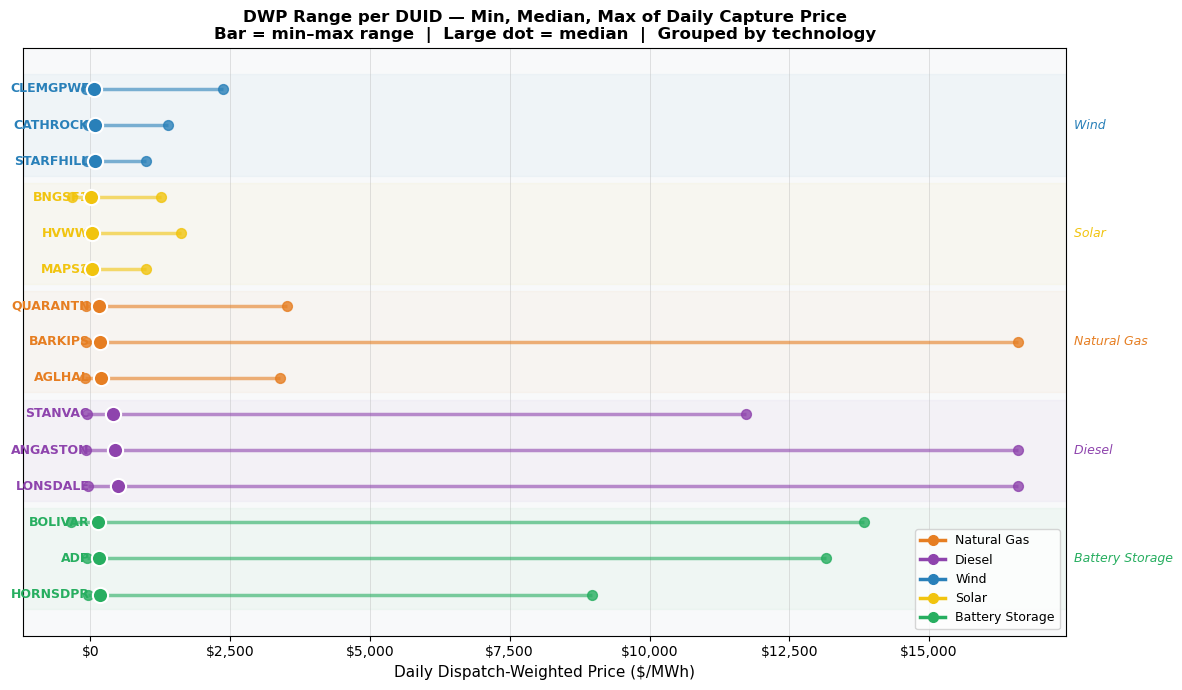

In [ ]:
COLORS = {'Natural Gas': '#e67e22', 'Diesel': '#8e44ad',
          'Wind': '#2980b9', 'Solar': '#f1c40f', 'Battery Storage': '#27ae60'}

# Order DUIDs: group by TECH, sort each group by median DWP descending
plot_order = (
    duid_range
    .sort_values(['TECH', 'median'], ascending=[True, False])
    ['DUID'].tolist()
)
y_pos  = {duid: i for i, duid in enumerate(plot_order)}
n_duids = len(plot_order)

fig, ax = plt.subplots(figsize=(12, 7))

# Draw one dumbbell per DUID: line from min to max, dot at median
for _, row in duid_range.iterrows():
    y     = y_pos[row['DUID']]
    color = COLORS[row['TECH']]

    # Range bar (min → max)
    ax.hlines(y, row['min'], row['max'], color=color, linewidth=2.5, alpha=0.6)

    # End caps: min and max
    ax.scatter(row['min'],    y, color=color, s=50,  zorder=4, alpha=0.8)
    ax.scatter(row['max'],    y, color=color, s=50,  zorder=4, alpha=0.8)

    # Median dot (larger, white-edged)
    ax.scatter(row['median'], y, color=color, s=120, zorder=5,
               edgecolors='white', linewidths=1.5)

    # DUID label on the left
    ax.text(-15, y, row['DUID'], va='center', ha='right', fontsize=9,
            color=color, fontweight='bold')

# Technology group separators and labels
tech_groups = duid_range.sort_values(['TECH', 'median'], ascending=[True, False]).groupby('TECH', sort=False)
for tech, grp in tech_groups:
    ys = [y_pos[d] for d in grp['DUID']]
    mid = np.mean(ys)
    ax.axhspan(min(ys) - 0.4, max(ys) + 0.4, alpha=0.04, color=COLORS[tech])
    ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 600,
            mid, f'  {tech}', va='center', fontsize=9,
            color=COLORS[tech], fontstyle='italic')

ax.set_yticks([])
ax.set_xlabel('Daily Dispatch-Weighted Price ($/MWh)', fontsize=11)
ax.set_title(
    'DWP Range per DUID — Min, Median, Max of Daily Capture Price\n'
    'Bar = min–max range  |  Large dot = median  |  Grouped by technology',
    fontsize=12, fontweight='bold'
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', linewidth=0.5, alpha=0.5)
ax.set_facecolor('#f8f9fa')

# Legend
handles = [mlines.Line2D([0], [0], color=COLORS[t], linewidth=2.5,
           marker='o', markersize=7, label=t) for t in COLORS]
ax.legend(handles=handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

In [46]:
df_long


,DUID,REGION,TECH,dispatch_MW,SA1_Price,SA1_Demand,year,month,hour,dayofweek,is_weekend,quarter,season,is_peak,financial_year,dispatch_MWh
SETTLEMENTDATE,,,,,,,,,,,,,,,,
2022-07-01 00:04:59,ADP,SA1,Battery Storage,0.00000,379.96000,1654.10,2022,7,0,4,False,3,Winter,False,2022,0.000000
2022-07-01 00:04:59,AGLHAL,SA1,Natural Gas,0.00000,379.96000,1654.10,2022,7,0,4,False,3,Winter,False,2022,0.000000
2022-07-01 00:04:59,ANGASTON,SA1,Diesel,36.00000,379.96000,1654.10,2022,7,0,4,False,3,Winter,False,2022,3.000000
2022-07-01 00:04:59,BARKIPS,SA1,Natural Gas,111.05000,379.96000,1654.10,2022,7,0,4,False,3,Winter,False,2022,9.254167
2022-07-01 00:04:59,BNGSF1,SA1,Solar,0.00000,379.96000,1654.10,2022,7,0,4,False,3,Winter,False,2022,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-30 23:59:59,LONSDALE,SA1,Diesel,0.00000,204.47554,1614.26,2024,6,23,6,True,2,Winter,False,2023,0.000000
2024-06-30 23:59:59,MAPS2,SA1,Solar,0.00000,204.47554,1614.26,2024,6,23,6,True,2,Winter,False,2023,0.000000
2024-06-30 23:59:59,QUARANTN,SA1,Natural Gas,0.00000,204.47554,1614.26,2024,6,23,6,True,2,Winter,False,2023,0.000000


### Total electricity generation by each technology 

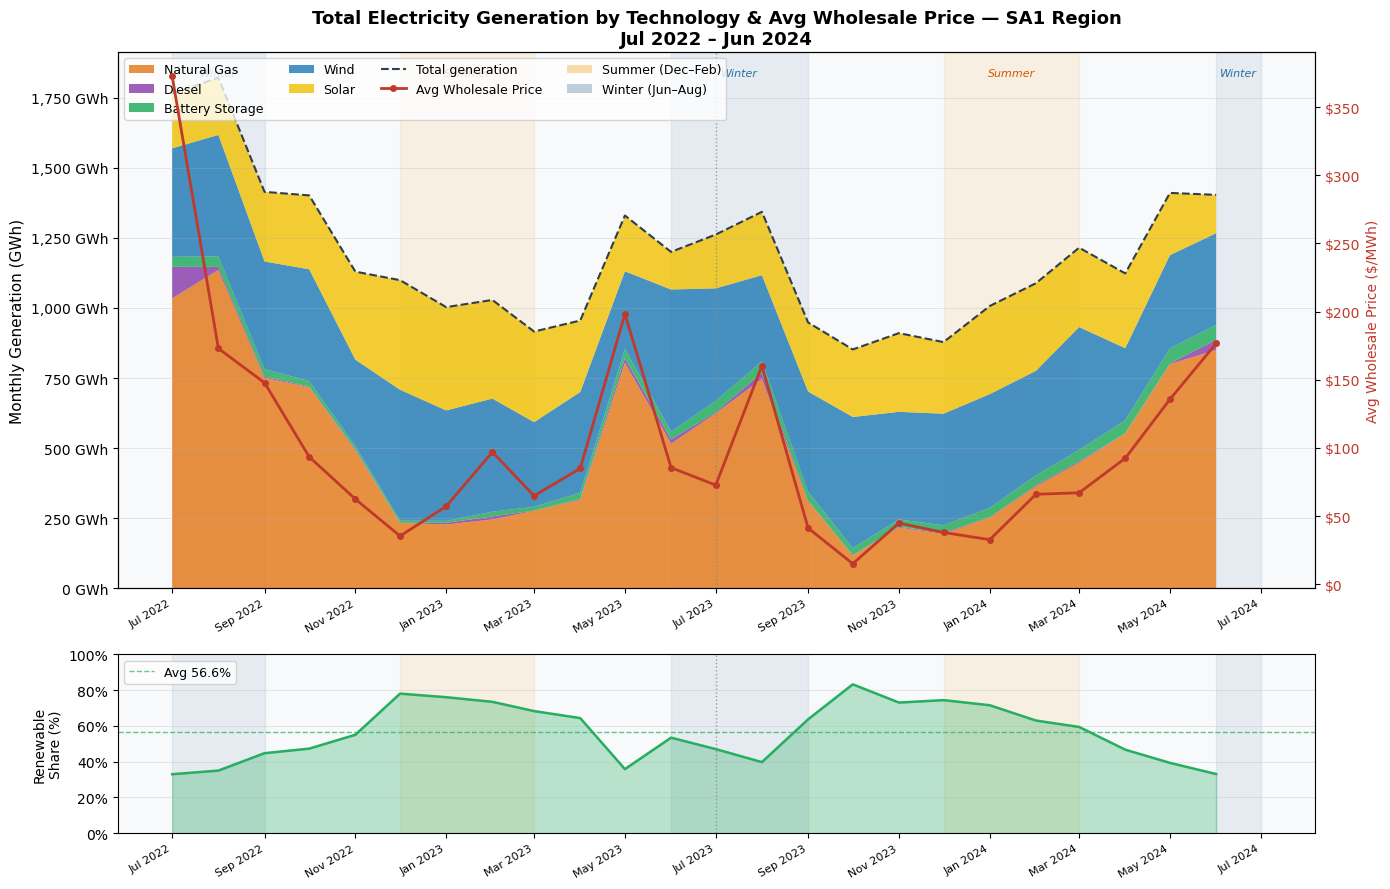

In [ ]:
gen = df_long[df_long['dispatch_MWh'] > 0].copy()
gen['month_start'] = gen.index.to_period('M').to_timestamp()

monthly = (
    gen.groupby(['month_start', 'TECH'])['dispatch_MW']
    .sum().div(1_000)
    .reset_index(name='GWh')
    .pivot(index='month_start', columns='TECH', values='GWh')
    .fillna(0)
)
stack_order = ['Natural Gas', 'Diesel', 'Battery Storage', 'Wind', 'Solar']
stack_order = [t for t in stack_order if t in monthly.columns]
monthly = monthly[stack_order]
total   = monthly.sum(axis=1)

# Monthly average wholesale price (deduplicated — one price per timestamp)
market = df_long[~df_long.index.duplicated(keep='first')][['SA1_Price']].copy()
market['month_start'] = market.index.to_period('M').to_timestamp()
monthly_price = market.groupby('month_start')['SA1_Price'].mean()

COLORS = {'Natural Gas': '#e67e22', 'Diesel': '#8e44ad',
          'Wind': '#2980b9', 'Solar': '#f1c40f', 'Battery Storage': '#27ae60'}

SUMMER_BANDS = [
    (pd.Timestamp('2022-12-01'), pd.Timestamp('2023-03-01')),
    (pd.Timestamp('2023-12-01'), pd.Timestamp('2024-03-01')),
]
WINTER_BANDS = [
    (pd.Timestamp('2022-07-01'), pd.Timestamp('2022-09-01')),
    (pd.Timestamp('2023-06-01'), pd.Timestamp('2023-09-01')),
    (pd.Timestamp('2024-06-01'), pd.Timestamp('2024-07-01')),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                                gridspec_kw={'height_ratios': [3, 1]})

# --- Top: stacked generation + price overlay ---
ax1.stackplot(
    monthly.index,
    [monthly[t] for t in stack_order],
    labels=stack_order,
    colors=[COLORS[t] for t in stack_order],
    alpha=0.85
)
ax1.plot(monthly.index, total, color='#2c3e50', linewidth=1.5,
         linestyle='--', label='Total generation', zorder=5)

# Price on secondary y-axis
ax1b = ax1.twinx()
ax1b.plot(monthly_price.index, monthly_price.values,
          color='#c0392b', linewidth=2, linestyle='-',
          marker='o', markersize=4, label='Avg Wholesale Price', zorder=6)
ax1b.set_ylabel('Avg Wholesale Price ($/MWh)', fontsize=10, color='#c0392b')
ax1b.tick_params(axis='y', labelcolor='#c0392b')
ax1b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax1.set_ylabel('Monthly Generation (GWh)', fontsize=11)
ax1.set_title(
    'Total Electricity Generation by Technology & Avg Wholesale Price — SA1 Region\n'
    'Jul 2022 – Jun 2024',
    fontsize=13, fontweight='bold'
)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} GWh'))
ax1.set_facecolor('#f8f9fa')
ax1.grid(axis='y', linewidth=0.4, alpha=0.5)

# --- Bottom: renewable share ---
renewable_cols  = [t for t in ['Wind', 'Solar'] if t in monthly.columns]
renewable_share = monthly[renewable_cols].sum(axis=1) / total * 100
ax2.fill_between(monthly.index, renewable_share, alpha=0.3, color='#27ae60')
ax2.plot(monthly.index, renewable_share, color='#27ae60', linewidth=1.8)
ax2.axhline(renewable_share.mean(), color='#27ae60', linewidth=1,
            linestyle='--', alpha=0.7, label=f'Avg {renewable_share.mean():.1f}%')
ax2.set_ylabel('Renewable\nShare (%)', fontsize=10)
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.legend(fontsize=9, loc='upper left')
ax2.set_facecolor('#f8f9fa')
ax2.grid(axis='y', linewidth=0.4, alpha=0.5)

# --- Seasonal shading (both panels) ---
for ax in (ax1, ax2):
    for s, e in SUMMER_BANDS:
        ax.axvspan(s, e, color='#f39c12', alpha=0.10, zorder=0)
    for s, e in WINTER_BANDS:
        ax.axvspan(s, e, color='#5d8aa8', alpha=0.12, zorder=0)
    ax.axvline(pd.Timestamp('2023-07-01'), color='#7f8c8d',
               linewidth=1, linestyle=':', alpha=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

# Season labels on top panel
for s, e in SUMMER_BANDS:
    ax1.text(s + (e-s)/2, ax1.get_ylim()[1]*0.97, 'Summer',
             ha='center', va='top', fontsize=8, color='#d35400', fontstyle='italic')
for s, e in WINTER_BANDS:
    ax1.text(s + (e-s)/2, ax1.get_ylim()[1]*0.97, 'Winter',
             ha='center', va='top', fontsize=8, color='#2471a3', fontstyle='italic')

# Combined legend: tech stacks + price line + seasons
season_handles = [
    mpatches.Patch(facecolor='#f39c12', alpha=0.35, label='Summer (Dec–Feb)'),
    mpatches.Patch(facecolor='#5d8aa8', alpha=0.40, label='Winter (Jun–Aug)'),
]
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1b.get_legend_handles_labels()
ax1.legend(handles=h1 + h2 + season_handles,
           labels=l1 + l2 + ['Summer (Dec–Feb)', 'Winter (Jun–Aug)'],
           loc='upper left', fontsize=9, ncol=4)

plt.tight_layout()
plt.show()

In [34]:
# Joined summary table: one row per DUID, all key metrics side-by-side
active = df_long[df_long['dispatch_MWh'] > 0]

# Base metrics grouped by DUID + TECH
base = (
    df_long.groupby(['DUID', 'TECH'])
    .agg(
        avg_demand_MW   = ('SA1_Demand',   'mean'),   # average regional demand while generator is in dataset
        total_dispatch_MWh = ('dispatch_MWh', 'sum'), # includes negative (charging) intervals
    )
    .reset_index()
)

# DWP — requires active dispatch only (dispatch_MWh > 0)
dwp = (
    active
    .assign(px_e = active['SA1_Price'] * active['dispatch_MWh'])
    .groupby(['DUID', 'TECH'])
    .apply(lambda g: g['px_e'].sum() / g['dispatch_MWh'].sum(), include_groups=False)
    .reset_index(name='DWP_$/MWh')
)

# Join and sort by DWP descending
summary = (
    base.merge(dwp, on=['DUID', 'TECH'])
    .sort_values('DWP_$/MWh', ascending=False)
    .reset_index(drop=True)
    .round(2)
)

summary

,DUID,TECH,avg_demand_MW,total_dispatch_MWh,DWP_$/MWh
0,STANVAC,Diesel,1289.38,8301.36,1046.04
1,ANGASTON,Diesel,1289.38,8450.69,823.68
2,LONSDALE,Diesel,1289.38,5864.68,804.55
3,AGLHAL,Natural Gas,1289.38,122686.98,457.30
4,HORNSDPR,Battery Storage,1289.38,52740.07,407.53
5,BOLIVAR,Battery Storage,1289.38,1152.36,368.28
6,ADP,Battery Storage,1289.38,5560.59,313.28
7,BARKIPS,Natural Gas,1289.38,572905.54,261.94
8,QUARANTN,Natural Gas,1289.38,322635.13,250.03
9,CATHROCK,Wind,1289.38,275094.41,91.94


### Monthly average spot price and total demand 

In [ ]:
# Market-wide — deduplicate so each 5-min interval is counted once
market = df_long[~df_long.index.duplicated(keep='first')][['SA1_Price', 'SA1_Demand']].copy()
market['month_start'] = market.index.to_period('M').to_timestamp()

# Total demand: SA1_Demand (MW) × 5/60 h = MWh per interval, summed to GWh per month
INTERVAL_H = 5 / 60
market['demand_MWh'] = market['SA1_Demand'] * INTERVAL_H

mkt = market.groupby('month_start').agg(
    mean_price   = ('SA1_Price',   'mean'),
    p25_price    = ('SA1_Price',   lambda x: x.quantile(0.25)),
    p75_price    = ('SA1_Price',   lambda x: x.quantile(0.75)),
    total_demand_GWh = ('demand_MWh', lambda x: x.sum() / 1_000),
).reset_index()

# Seasonal bands (Southern Hemisphere)
SUMMER_BANDS = [
    (pd.Timestamp('2022-12-01'), pd.Timestamp('2023-03-01')),
    (pd.Timestamp('2023-12-01'), pd.Timestamp('2024-03-01')),
]
WINTER_BANDS = [
    (pd.Timestamp('2022-07-01'), pd.Timestamp('2022-09-01')),
    (pd.Timestamp('2023-06-01'), pd.Timestamp('2023-09-01')),
    (pd.Timestamp('2024-06-01'), pd.Timestamp('2024-07-01')),
]

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# --- Price (left axis) ---
ax1.fill_between(mkt['month_start'], mkt['p25_price'], mkt['p75_price'],
                 color='#c0392b', alpha=0.15)
ax1.plot(mkt['month_start'], mkt['mean_price'],
         color='#c0392b', linewidth=2.2, label='Avg Spot Price ($/MWh)')
ax1.axhline(mkt['mean_price'].mean(), color='#c0392b', linewidth=0.9,
            linestyle='--', alpha=0.6,
            label=f'Price avg = ${mkt["mean_price"].mean():.0f}/MWh')

# --- Total demand (right axis) ---
ax2.plot(mkt['month_start'], mkt['total_demand_GWh'],
         color='#2c3e50', linewidth=1.8, linestyle='-.')
ax2.axhline(mkt['total_demand_GWh'].mean(), color='#2c3e50', linewidth=0.9,
            linestyle='--', alpha=0.6,
            label=f'Demand avg = {mkt["total_demand_GWh"].mean():.0f} GWh/month')

# --- Seasonal shading ---
for start, end in SUMMER_BANDS:
    ax1.axvspan(start, end, color='#f39c12', alpha=0.10, zorder=0)
for start, end in WINTER_BANDS:
    ax1.axvspan(start, end, color='#5d8aa8', alpha=0.12, zorder=0)

# Season labels — placed after y-limits are set by data
ax1.autoscale()
y_top = ax1.get_ylim()[1]
for start, end in SUMMER_BANDS:
    ax1.text(start + (end - start) / 2, y_top * 0.97, 'Summer',
             ha='center', va='top', fontsize=8, color='#d35400', fontstyle='italic')
for start, end in WINTER_BANDS:
    ax1.text(start + (end - start) / 2, y_top * 0.97, 'Winter',
             ha='center', va='top', fontsize=8, color='#2471a3', fontstyle='italic')

# FY boundary
ax1.axvline(pd.Timestamp('2023-07-01'), color='#7f8c8d',
            linewidth=1, linestyle=':', alpha=0.8)
ax1.text(pd.Timestamp('2023-07-01'), ax1.get_ylim()[0], ' FY split',
         fontsize=8, color='#7f8c8d', va='bottom')

# --- Axes formatting ---
ax1.set_ylabel('Avg Spot Price ($/MWh)', fontsize=11, color='#c0392b')
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2.set_ylabel('Total Demand (GWh / month)', fontsize=11, color='#2c3e50')
ax2.tick_params(axis='y', labelcolor='#2c3e50')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} GWh'))

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
ax1.set_facecolor('#f8f9fa')
ax1.grid(axis='y', linewidth=0.4, alpha=0.4)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
season_handles = [
    mpatches.Patch(facecolor='#f39c12', alpha=0.35, label='Summer (Dec–Feb)'),
    mpatches.Patch(facecolor='#5d8aa8', alpha=0.40, label='Winter (Jun–Aug)'),
]
ax1.legend(handles=h1 + h2 + season_handles, fontsize=9, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

print('--- Monthly total demand (GWh) ---')
print(mkt[['month_start', 'total_demand_GWh']].to_string(index=False))
print(f'\nFull-period total demand: {mkt["total_demand_GWh"].sum():,.1f} GWh')

AttributeError: 'RangeIndex' object has no attribute 'to_period'

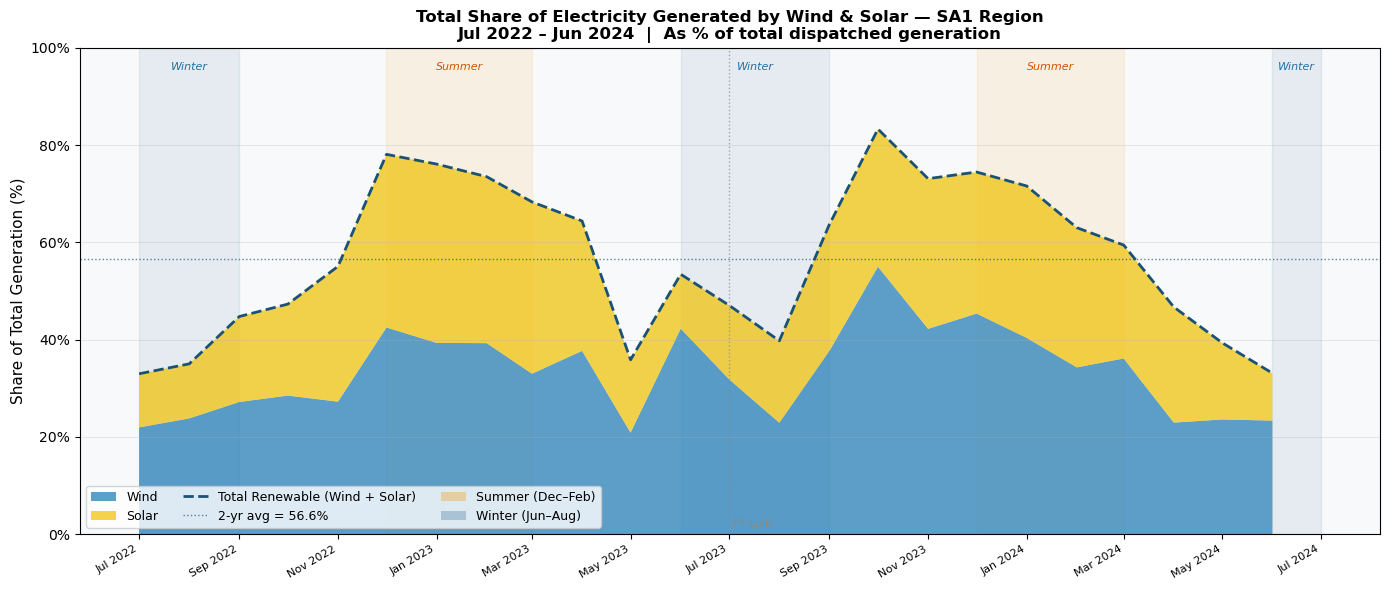

--- Monthly renewable share ---
TECH         Wind %  Solar %  Renewable %
month_start                              
2022-07-01     21.9     11.0         33.0
2022-08-01     23.8     11.2         35.0
2022-09-01     27.2     17.6         44.7
2022-10-01     28.5     18.8         47.3
2022-11-01     27.2     27.8         55.0
2022-12-01     42.5     35.6         78.1
2023-01-01     39.3     36.8         76.1
2023-02-01     39.3     34.2         73.5
2023-03-01     33.0     35.3         68.3
2023-04-01     37.7     26.7         64.4
2023-05-01     20.9     15.0         35.8
2023-06-01     42.2     11.2         53.4
2023-07-01     31.8     15.2         47.0
2023-08-01     22.9     16.9         39.7
2023-09-01     37.7     26.0         63.7
2023-10-01     55.0     28.3         83.3
2023-11-01     42.2     30.9         73.1
2023-12-01     45.3     29.1         74.4
2024-01-01     40.3     31.2         71.6
2024-02-01     34.3     28.7         63.0
2024-03-01     36.1     23.3         59.4
20

In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

gen = df_long[df_long['dispatch_MWh'] > 0].copy()
gen['month_start'] = gen.index.to_period('M').to_timestamp()

monthly_tech = (
    gen.groupby(['month_start', 'TECH'])['dispatch_MWh']
    .sum().div(1_000)
    .unstack('TECH').fillna(0)
)
monthly_tech['Total']       = monthly_tech.sum(axis=1)
monthly_tech['Wind %']      = monthly_tech['Wind']  / monthly_tech['Total'] * 100
monthly_tech['Solar %']     = monthly_tech['Solar'] / monthly_tech['Total'] * 100
monthly_tech['Renewable %'] = monthly_tech['Wind %'] + monthly_tech['Solar %']

SUMMER_BANDS = [
    (pd.Timestamp('2022-12-01'), pd.Timestamp('2023-03-01')),
    (pd.Timestamp('2023-12-01'), pd.Timestamp('2024-03-01')),
]
WINTER_BANDS = [
    (pd.Timestamp('2022-07-01'), pd.Timestamp('2022-09-01')),
    (pd.Timestamp('2023-06-01'), pd.Timestamp('2023-09-01')),
    (pd.Timestamp('2024-06-01'), pd.Timestamp('2024-07-01')),
]

fig, ax = plt.subplots(figsize=(14, 6))

# Stacked area: wind + solar share
ax.stackplot(
    monthly_tech.index,
    monthly_tech['Wind %'], monthly_tech['Solar %'],
    labels=['Wind', 'Solar'],
    colors=['#2980b9', '#f1c40f'],
    alpha=0.75
)

# Total renewable line
ax.plot(monthly_tech.index, monthly_tech['Renewable %'],
        color='#1a5276', linewidth=2, linestyle='--',
        label='Total Renewable (Wind + Solar)', zorder=5)

# 2-year average
avg = monthly_tech['Renewable %'].mean()
ax.axhline(avg, color='#1a5276', linewidth=1, linestyle=':',
           alpha=0.7, label=f'2-yr avg = {avg:.1f}%')

# Seasonal shading
for s, e in SUMMER_BANDS:
    ax.axvspan(s, e, color='#f39c12', alpha=0.10, zorder=0)
    ax.text(s + (e-s)/2, 97, 'Summer', ha='center', va='top',
            fontsize=8, color='#d35400', fontstyle='italic')
for s, e in WINTER_BANDS:
    ax.axvspan(s, e, color='#5d8aa8', alpha=0.12, zorder=0)
    ax.text(s + (e-s)/2, 97, 'Winter', ha='center', va='top',
            fontsize=8, color='#2471a3', fontstyle='italic')

ax.axvline(pd.Timestamp('2023-07-01'), color='#7f8c8d',
           linewidth=1, linestyle=':', alpha=0.7)
ax.text(pd.Timestamp('2023-07-01'), 1, ' FY split',
        fontsize=8, color='#7f8c8d', va='bottom')

season_handles = [
    mpatches.Patch(facecolor='#f39c12', alpha=0.35, label='Summer (Dec–Feb)'),
    mpatches.Patch(facecolor='#5d8aa8', alpha=0.40, label='Winter (Jun–Aug)'),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + season_handles, fontsize=9, loc='lower left', ncol=3)

ax.set_ylim(0, 100)
ax.set_ylabel('Share of Total Generation (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', linewidth=0.4, alpha=0.5)
ax.set_title(
    'Total Share of Electricity Generated by Wind & Solar — SA1 Region\n'
    'Jul 2022 – Jun 2024  |  As % of total dispatched generation',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('--- Monthly renewable share ---')
print(monthly_tech[['Wind %', 'Solar %', 'Renewable %']].round(1).to_string())
print(f'\n2-year average — Wind: {monthly_tech["Wind %"].mean():.1f}%  '
      f'Solar: {monthly_tech["Solar %"].mean():.1f}%  '
      f'Total renewable: {avg:.1f}%')

In [70]:
PATH_2 = '/Users/quinhuonn/Desktop/data_projects/ELECTRICITY/Nameplate capacity.xlsx'
capacity_ref = pd.read_excel(PATH_2)

In [71]:
capacity_ref

,Region,Asset Type,Site Name,Owner,Technology Type,Fuel Type,DUID,Number of Units,Lower Nameplate Capacity (MW),Upper Nameplate Capacity (MW),...,Dispatch Type,Full Commercial Use Date,Expected Closure Year,Closure Date,Status Bucket Summary,Fuel Bucket Summary,SurveyId,AEMO KCI Id,Survey Last Requested,Survey Version DateTime
0,SA1,Existing Plant,Adelaide Airport,Adelaide Airport Ltd,Solar PV - Fixed,Solar - Solar,NaN,16.0,NaN,0.06,...,NS,NaT,NaN,NaT,Existing less Announced Withdrawal,Solar,1536.0,NaN,2022-09-01,2018-05-27 23:01:44
1,SA1,Existing Plant,Adelaide Airport,Adelaide Airport Ltd,Solar PV - Fixed,Solar - Solar,NaN,2.0,NaN,0.02,...,NS,NaT,NaN,NaT,Existing less Announced Withdrawal,Solar,1536.0,NaN,2022-09-01,2018-05-27 23:01:44
2,SA1,Existing Plant,Adelaide Desalination Plant,South Australian Water Corporation,Storage - Battery,Other - Other,ADPBA1G,1.0,NaN,6.27,...,S,2022-05-01,2041.0,NaT,Existing less Announced Withdrawal,Battery Storage,1844.0,NaN,2023-04-01,2023-04-06 11:08:43
3,SA1,Existing Plant,Adelaide Desalination Plant,South Australian Water Corporation,Solar PV - Fixed,Solar - Solar,ADPPV1,4.0,NaN,2.75,...,SS,2022-05-01,2041.0,NaT,Existing less Announced Withdrawal,Solar,1844.0,NaN,2023-04-01,2023-04-06 11:08:43
4,SA1,Existing Plant,Adelaide Desalination Plant,South Australian Water Corporation,Solar PV - Fixed,Solar - Solar,ADPPV2,4.0,NaN,3.43,...,NS,2022-07-01,2041.0,NaT,Existing less Announced Withdrawal,Solar,1844.0,NaN,2023-04-01,2023-04-06 11:08:43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412,YATSF1,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaT,NaT
1413,YAWWF1,7.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaT,NaT
1414,YENDWF1,144.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaT,NaT
1415,NaN,635.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaT,NaT


In [76]:
# ── Merge capacity_ref with df_long to get nameplate capacity per DUID + technology ──
_duid_col = capacity_ref.columns[6]
_mw_col   = capacity_ref.columns[11]

# Clean nameplate lookup: sum unit rows sharing the same DUID
nameplate_lookup = (
    capacity_ref[[_duid_col, _mw_col]]
    .dropna(subset=[_duid_col])
    .rename(columns={_duid_col: 'DUID', _mw_col: 'nameplate_MW'})
    .groupby('DUID')['nameplate_MW']
    .sum()
    .reset_index()
)

# DUID → TECH mapping from dispatch data (one row per DUID)
duid_tech = (
    df_long[['DUID', 'TECH']]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Merge: only keep DUIDs present in the dispatch data
nameplate_by_tech = (
    duid_tech
    .merge(nameplate_lookup, on='DUID', how='left')
    .sort_values(['TECH', 'nameplate_MW'], ascending=[True, False])
    .reset_index(drop=True)
)

nameplate_by_tech.to_excel('fix_nameplate.xlsx')


In [77]:
fix_nameplate = pd.read_excel('fix_nameplate.xlsx')
fix_nameplate

,Unnamed: 0,DUID,TECH,nameplate_MW
0,0,ADP,Battery Storage,6.27
1,1,BOLIVAR,Battery Storage,2.46
2,2,HORNSDPR,Battery Storage,117.00
3,3,LONSDALE,Diesel,20.70
4,4,ANGASTON,Diesel,21.60
5,5,STANVAC,Diesel,46.80
6,6,AGLHAL,Natural Gas,68.00
7,7,BARKIPS,Natural Gas,210.00
8,8,QUARANTN,Natural Gas,128.00
9,9,BNGSF1,Solar,135.00


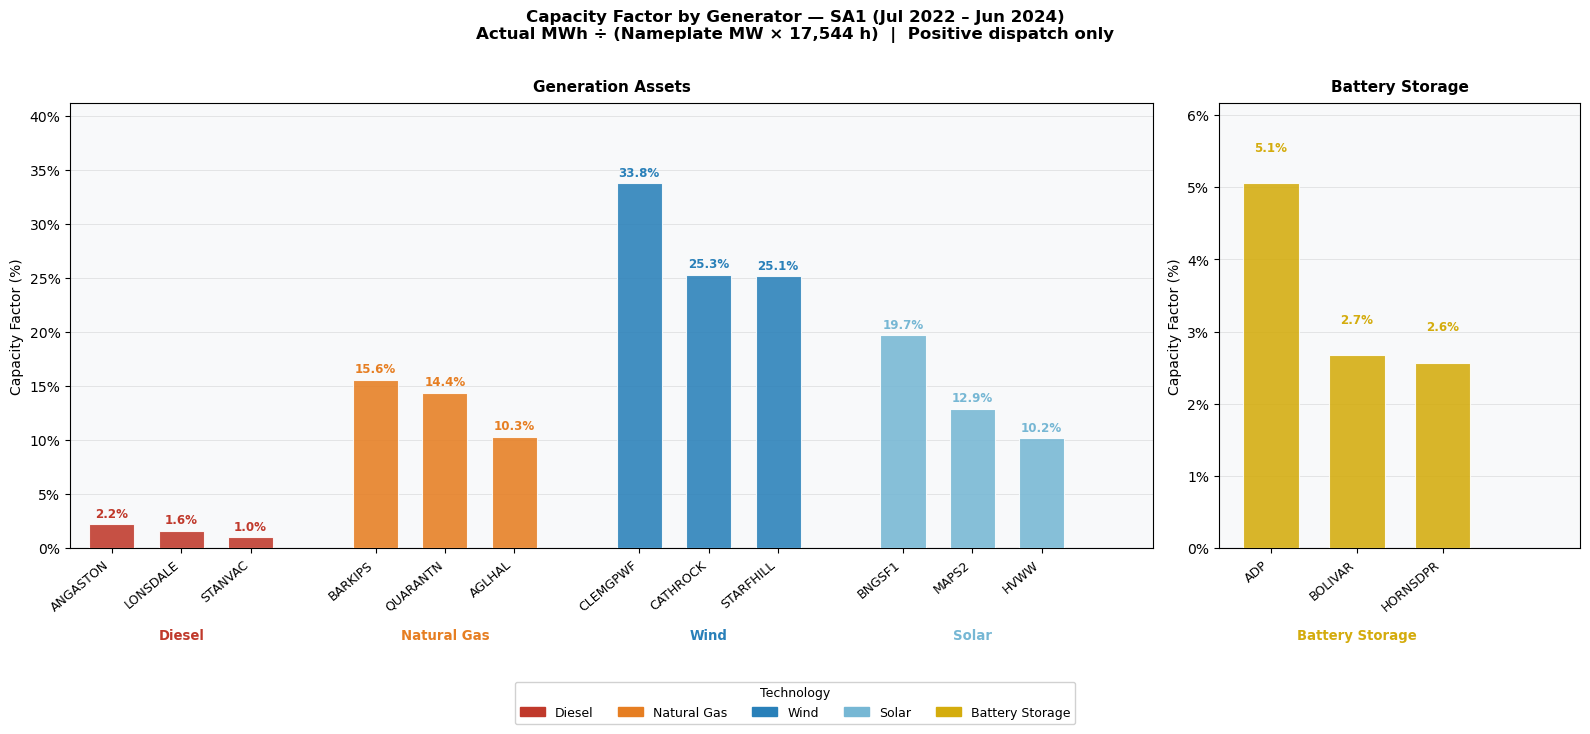

In [82]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

# ── Capacity Factor = actual MWh generated / (nameplate MW × period hours) ──
INTERVAL_H  = 5 / 60
total_hours = (df_long.index.max() - df_long.index.min()).total_seconds() / 3600

actual_gen = (
    df_long[df_long['dispatch_MW'] > 0]
    .groupby('DUID')['dispatch_MWh']
    .sum()
    .reset_index()
    .rename(columns={'dispatch_MWh': 'actual_MWh'})
)

cf = actual_gen.merge(fix_nameplate[['DUID', 'TECH', 'nameplate_MW']], on='DUID', how='inner')
cf['capacity_factor'] = cf['actual_MWh'] / (cf['nameplate_MW'] * total_hours)
cf = cf.sort_values(['TECH', 'capacity_factor'], ascending=[True, False]).reset_index(drop=True)

COLORS = {
    'Diesel'          : '#c0392b',
    'Natural Gas'     : '#e67e22',
    'Battery Storage' : '#d4ac0d',
    'Wind'            : '#2980b9',
    'Solar'           : '#76b7d4',
}

GEN_TECHS  = ['Diesel', 'Natural Gas', 'Wind', 'Solar']
BATT_TECHS = ['Battery Storage']

cf_gen  = cf[cf['TECH'].isin(GEN_TECHS)].copy()
cf_batt = cf[cf['TECH'].isin(BATT_TECHS)].copy()

def build_positions(df, tech_order, group_gap=0.8, bar_width=0.65):
    positions, tick_pos, tick_labels, group_mids, group_names = [], [], [], [], []
    x = 0
    for tech in tech_order:
        grp = df[df['TECH'] == tech]
        if grp.empty:
            continue
        gp = [x + i for i in range(len(grp))]
        positions.extend(zip(gp, grp['capacity_factor'], grp['DUID'], [tech]*len(grp)))
        tick_pos.extend(gp)
        tick_labels.extend(grp['DUID'].tolist())
        group_mids.append(np.mean(gp))
        group_names.append(tech)
        x += len(grp) + group_gap
    return positions, tick_pos, tick_labels, group_mids, group_names, x - group_gap

def draw_panel(ax, positions, tick_pos, tick_labels, group_mids, group_names,
               x_max, bar_width=0.65, title=''):
    for xp, cf_val, duid, tech in positions:
        ax.bar(xp, cf_val * 100, width=bar_width,
               color=COLORS[tech], edgecolor='white', linewidth=0.8,
               alpha=0.88, zorder=3)
        ax.text(xp, cf_val * 100 + 0.4, f'{cf_val*100:.1f}%',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold',
                color=COLORS[tech])
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=40, ha='right', fontsize=9)
    for mid, name in zip(group_mids, group_names):
        ax.text(mid, -0.18, name, ha='center', va='top', fontsize=9.5,
                fontweight='bold', color=COLORS[name],
                transform=ax.get_xaxis_transform())
    y_max = max(v for _, v, _, _ in positions) * 100
    ax.set_xlim(-0.6, x_max + 0.6)
    ax.set_ylim(0, y_max * 1.22)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))
    ax.axhline(0, color='#bbb', linewidth=0.8)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5, zorder=0)
    ax.set_facecolor('#f8f9fa')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel('Capacity Factor (%)', fontsize=10)

# ── Figure: two panels ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                                gridspec_kw={'width_ratios': [3, 1]})

pos_gen,  tp_gen,  tl_gen,  gm_gen,  gn_gen,  xmax_gen  = build_positions(
    cf_gen,  ['Diesel', 'Natural Gas', 'Wind', 'Solar'])
pos_batt, tp_batt, tl_batt, gm_batt, gn_batt, xmax_batt = build_positions(
    cf_batt, ['Battery Storage'])

draw_panel(ax1, pos_gen,  tp_gen,  tl_gen,  gm_gen,  gn_gen,  xmax_gen,
           title='Generation Assets')
draw_panel(ax2, pos_batt, tp_batt, tl_batt, gm_batt, gn_batt, xmax_batt,
           title='Battery Storage')

# Shared legend
legend_handles = [mpatches.Patch(color=COLORS[t], label=t)
                  for t in ['Diesel','Natural Gas','Wind','Solar','Battery Storage']
                  if t in cf['TECH'].values]
fig.legend(handles=legend_handles, fontsize=9, loc='lower center', ncol=5,
           title='Technology', title_fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    f'Capacity Factor by Generator — SA1 (Jul 2022 – Jun 2024)\n'
    f'Actual MWh ÷ (Nameplate MW × {total_hours:,.0f} h)  |  Positive dispatch only',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


/var/folders/fs/vpv7t9012wxdx__nwt82lmpm0000gn/T/ipykernel_87819/1094196641.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.98])


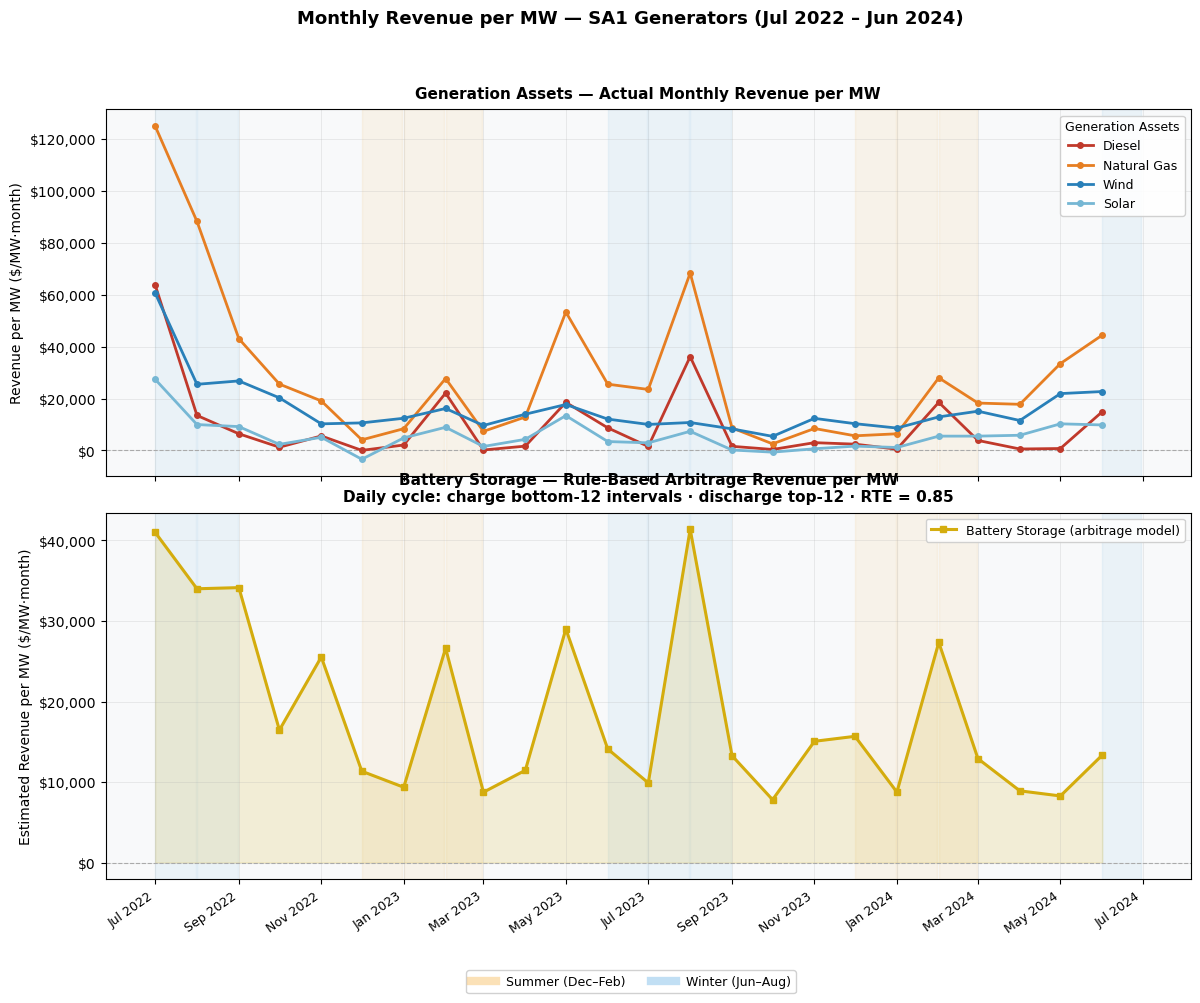

In [83]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import pandas as pd
import numpy as np

# ═══════════════════════════════════════════════════════════════════════
# PANEL 1 — Generation Assets: actual monthly revenue per MW by TECH
# ═══════════════════════════════════════════════════════════════════════
gen = df_long.copy()
gen['month_start'] = gen.index.to_period('M').to_timestamp()
gen['revenue']     = gen['SA1_Price'] * gen['dispatch_MWh']

monthly_rev = (
    gen.groupby(['DUID', 'TECH', 'month_start'])['revenue']
    .sum().reset_index()
    .merge(fix_nameplate[['DUID', 'nameplate_MW']], on='DUID', how='inner')
)

GEN_TECHS = ['Diesel', 'Natural Gas', 'Wind', 'Solar']
tech_monthly_gen = (
    monthly_rev[monthly_rev['TECH'].isin(GEN_TECHS)]
    .groupby(['TECH', 'month_start'])
    .apply(lambda g: g['revenue'].sum() / g['nameplate_MW'].sum(), include_groups=False)
    .reset_index(name='rev_per_MW')
)

# ═══════════════════════════════════════════════════════════════════════
# PANEL 2 — Battery Storage: rule-based arbitrage dispatch model
# Charge during cheapest N intervals per day, discharge during dearest N
# Revenue per MW = (top_N_prices − bottom_N_prices ÷ RTE) × INTERVAL_H
# ═══════════════════════════════════════════════════════════════════════
N_INTERVALS = 12    # 12 × 5-min = 1 h charge window, 1 h discharge window
RTE         = 0.85  # round-trip efficiency (Li-ion typical)
INTERVAL_H  = 5 / 60

price_ts = (
    df_long[~df_long.index.duplicated(keep='first')][['SA1_Price']]
    .reset_index()
    .rename(columns={'SETTLEMENTDATE': 'ts', 'SA1_Price': 'price'})
)
price_ts['date']        = price_ts['ts'].dt.date
price_ts['month_start'] = price_ts['ts'].dt.to_period('M').dt.to_timestamp()

def daily_arb(day_prices):
    s = day_prices.sort_values()
    discharge_rev = s.iloc[-N_INTERVALS:].sum()
    charge_cost   = s.iloc[:N_INTERVALS].sum()
    return (discharge_rev - charge_cost / RTE) * INTERVAL_H

daily_rev = (
    price_ts.groupby('date')['price']
    .apply(daily_arb)
    .reset_index(name='daily_rev_per_MW')
)
daily_rev['month_start'] = pd.to_datetime(daily_rev['date']).dt.to_period('M').dt.to_timestamp()

monthly_batt = (
    daily_rev.groupby('month_start')['daily_rev_per_MW']
    .sum().reset_index()
    .rename(columns={'daily_rev_per_MW': 'rev_per_MW'})
)

# ── Colours ───────────────────────────────────────────────────────────
COLORS = {
    'Diesel'          : '#c0392b',
    'Natural Gas'     : '#e67e22',
    'Battery Storage' : '#d4ac0d',
    'Wind'            : '#2980b9',
    'Solar'           : '#76b7d4',
}

# ── Seasonal shading ──────────────────────────────────────────────────
def add_seasons(ax, months):
    for m in months:
        if m.month in [12, 1, 2]:
            ax.axvspan(m, m + pd.offsets.MonthEnd(1), color='#f39c12', alpha=0.07, zorder=0)
        elif m.month in [6, 7, 8]:
            ax.axvspan(m, m + pd.offsets.MonthEnd(1), color='#3498db', alpha=0.07, zorder=0)

all_months = pd.date_range(tech_monthly_gen['month_start'].min(),
                           tech_monthly_gen['month_start'].max(), freq='MS')

# ── Figure: two stacked panels, shared x-axis ─────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                                gridspec_kw={'hspace': 0.10})

# ── Panel 1: Generation Assets ────────────────────────────────────────
for tech in ['Diesel', 'Natural Gas', 'Wind', 'Solar']:
    ts = tech_monthly_gen[tech_monthly_gen['TECH'] == tech].sort_values('month_start')
    if ts.empty:
        continue
    ax1.plot(ts['month_start'], ts['rev_per_MW'],
             color=COLORS[tech], linewidth=2, marker='o', markersize=4,
             label=tech, zorder=4)

ax1.axhline(0, color='#aaa', linewidth=0.8, linestyle='--', zorder=2)
add_seasons(ax1, all_months)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))
ax1.set_ylabel('Revenue per MW ($/MW·month)', fontsize=10)
ax1.set_facecolor('#f8f9fa')
ax1.grid(linewidth=0.4, alpha=0.4, zorder=0)
ax1.legend(fontsize=9, loc='upper right', title='Generation Assets',
           title_fontsize=9, framealpha=0.9)
ax1.set_title('Generation Assets — Actual Monthly Revenue per MW',
              fontsize=11, fontweight='bold', pad=8)

# ── Panel 2: Battery Arbitrage ────────────────────────────────────────
ax2.plot(monthly_batt['month_start'], monthly_batt['rev_per_MW'],
         color=COLORS['Battery Storage'], linewidth=2.2, marker='s',
         markersize=5, label='Battery Storage (arbitrage model)', zorder=4)
ax2.fill_between(monthly_batt['month_start'], monthly_batt['rev_per_MW'],
                 alpha=0.15, color=COLORS['Battery Storage'], zorder=1)
ax2.axhline(0, color='#aaa', linewidth=0.8, linestyle='--', zorder=2)
add_seasons(ax2, all_months)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))
ax2.set_ylabel('Estimated Revenue per MW ($/MW·month)', fontsize=10)
ax2.set_facecolor('#f8f9fa')
ax2.grid(linewidth=0.4, alpha=0.4, zorder=0)
ax2.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax2.set_title(
    f'Battery Storage — Rule-Based Arbitrage Revenue per MW\n'
    f'Daily cycle: charge bottom-{N_INTERVALS} intervals · discharge top-{N_INTERVALS} · RTE = {RTE}',
    fontsize=11, fontweight='bold', pad=8
)

# Shared season legend at bottom
season_handles = [
    mlines.Line2D([0],[0], color='#f39c12', linewidth=6, alpha=0.3, label='Summer (Dec–Feb)'),
    mlines.Line2D([0],[0], color='#3498db', linewidth=6, alpha=0.3, label='Winter (Jun–Aug)'),
]
fig.legend(handles=season_handles, fontsize=9, loc='lower center', ncol=2,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Monthly Revenue per MW — SA1 Generators (Jul 2022 – Jun 2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()


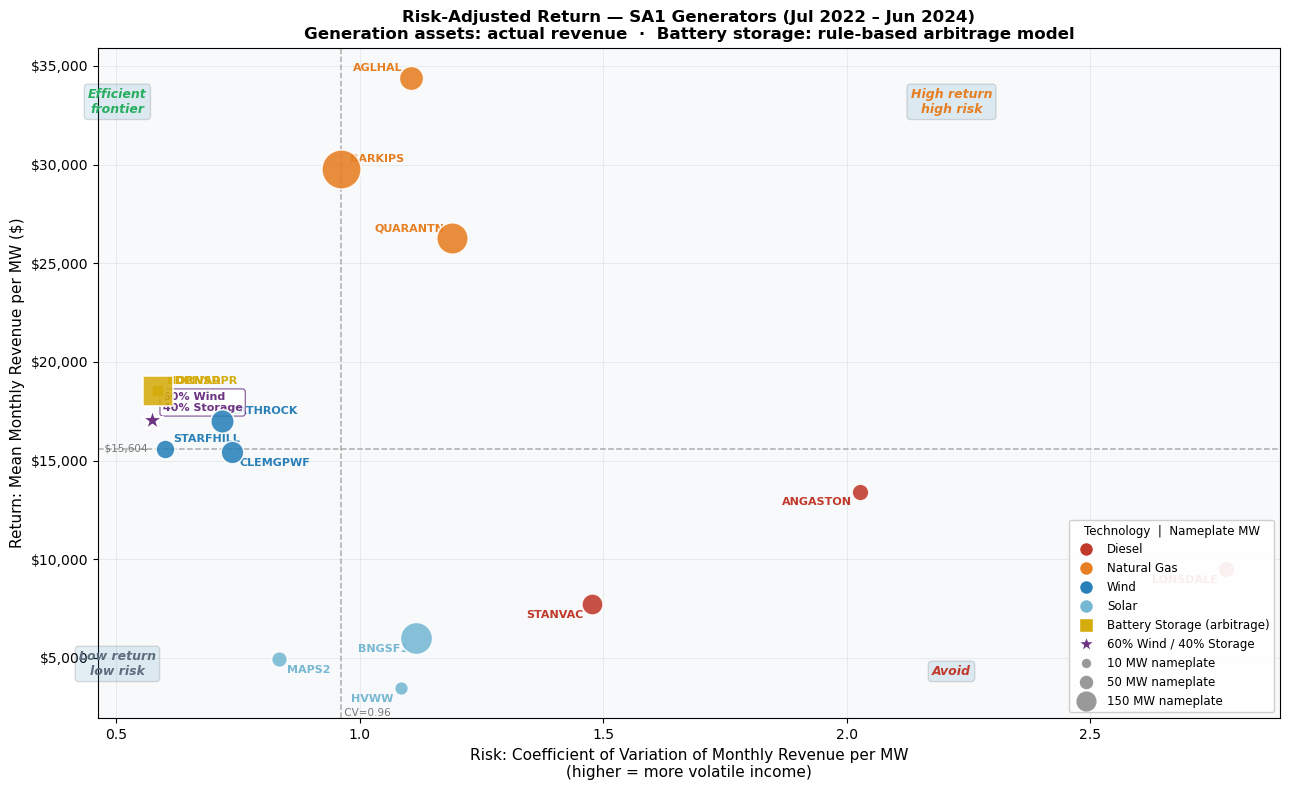

--- Risk–Return summary ---
     DUID            TECH  nameplate_MW  mean_rev  std_rev   cv
   AGLHAL     Natural Gas         68.00  34378.13 38019.95 1.11
  BARKIPS     Natural Gas        210.00  29775.39 28653.26 0.96
 QUARANTN     Natural Gas        128.00  26258.74 31252.52 1.19
      ADP Battery Storage          6.27  18515.66 10849.78 0.59
  BOLIVAR Battery Storage          2.46  18515.66 10849.78 0.59
 HORNSDPR Battery Storage        117.00  18515.66 10849.78 0.59
 CATHROCK            Wind         62.00  16997.51 12199.75 0.72
STARFHILL            Wind         33.00  15604.02  9362.43 0.60
 CLEMGPWF            Wind         56.70  15434.13 11371.92 0.74
 ANGASTON          Diesel         21.60  13427.14 27223.20 2.03
 LONSDALE          Diesel         20.70   9497.61 26401.33 2.78
  STANVAC          Diesel         46.80   7731.11 11421.23 1.48
   BNGSF1           Solar        135.00   5978.61  6671.30 1.12
    MAPS2           Solar         16.80   4926.52  4105.02 0.83
     HVWW   

In [86]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

COLORS = {
    'Diesel'          : '#c0392b',
    'Natural Gas'     : '#e67e22',
    'Battery Storage' : '#d4ac0d',
    'Wind'            : '#2980b9',
    'Solar'           : '#76b7d4',
}

# ── Generation Assets: actual monthly revenue per DUID ───────────────
gen = df_long.copy()
gen['month_start'] = gen.index.to_period('M').to_timestamp()
gen['revenue']     = gen['SA1_Price'] * gen['dispatch_MWh']

nameplate = fix_nameplate.set_index('DUID')['nameplate_MW']

monthly_gen = (
    gen.groupby(['DUID', 'TECH', 'month_start'])['revenue']
    .sum().reset_index()
    .join(nameplate, on='DUID')
    .dropna(subset=['nameplate_MW'])
)
monthly_gen['rev_per_MW'] = monthly_gen['revenue'] / monthly_gen['nameplate_MW']

GEN_TECHS = ['Diesel', 'Natural Gas', 'Wind', 'Solar']
rr_gen = (
    monthly_gen[monthly_gen['TECH'].isin(GEN_TECHS)]
    .groupby(['DUID', 'TECH'])['rev_per_MW']
    .agg(mean_rev='mean', std_rev='std')
    .reset_index()
)
rr_gen['cv'] = rr_gen['std_rev'] / rr_gen['mean_rev'].abs()
rr_gen = rr_gen.join(nameplate, on='DUID')

# ── Battery Storage: rule-based arbitrage revenue per MW ─────────────
N_INTERVALS = 12
RTE         = 0.85
INTERVAL_H  = 5 / 60

price_ts = (
    df_long[~df_long.index.duplicated(keep='first')][['SA1_Price']]
    .reset_index()
    .rename(columns={'SETTLEMENTDATE': 'ts', 'SA1_Price': 'price'})
)
price_ts['date']        = price_ts['ts'].dt.date
price_ts['month_start'] = price_ts['ts'].dt.to_period('M').dt.to_timestamp()

def daily_arb(day_prices):
    s = day_prices.sort_values()
    return (s.iloc[-N_INTERVALS:].sum() - s.iloc[:N_INTERVALS].sum() / RTE) * INTERVAL_H

monthly_batt_rev = (
    price_ts.groupby(['date', 'month_start'])['price']
    .apply(daily_arb, include_groups=False)
    .reset_index(name='daily_rev_per_MW')
    .groupby('month_start')['daily_rev_per_MW']
    .sum().reset_index(name='rev_per_MW')
)

batt_duids = fix_nameplate[fix_nameplate['TECH'] == 'Battery Storage'][['DUID','TECH','nameplate_MW']].copy()
batt_duids['mean_rev'] = monthly_batt_rev['rev_per_MW'].mean()
batt_duids['std_rev']  = monthly_batt_rev['rev_per_MW'].std()
batt_duids['cv']       = batt_duids['std_rev'] / batt_duids['mean_rev'].abs()

# ── 60 % Wind / 40 % Storage portfolio ───────────────────────────────
wind_monthly = (
    monthly_gen[monthly_gen['TECH'] == 'Wind']
    .groupby('month_start')
    .apply(lambda g: g['revenue'].sum() / g['nameplate_MW'].sum(), include_groups=False)
    .reset_index(name='wind_rev_per_MW')
)
port = wind_monthly.merge(
    monthly_batt_rev.rename(columns={'rev_per_MW': 'batt_rev_per_MW'}),
    on='month_start', how='inner'
)
port['port_rev_per_MW'] = 0.60 * port['wind_rev_per_MW'] + 0.40 * port['batt_rev_per_MW']

port_mean = port['port_rev_per_MW'].mean()
port_std  = port['port_rev_per_MW'].std()
port_cv   = port_std / abs(port_mean)

# ── Combine ───────────────────────────────────────────────────────────
rr = pd.concat(
    [rr_gen, batt_duids[['DUID','TECH','nameplate_MW','mean_rev','std_rev','cv']]],
    ignore_index=True
)
cap_min, cap_max = rr['nameplate_MW'].min(), rr['nameplate_MW'].max()
rr['marker_size'] = 80 + 720 * (rr['nameplate_MW'] - cap_min) / (cap_max - cap_min)

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))

for _, row in rr.iterrows():
    marker = 's' if row['TECH'] == 'Battery Storage' else 'o'
    ax.scatter(row['cv'], row['mean_rev'], s=row['marker_size'],
               color=COLORS[row['TECH']], edgecolors='white',
               linewidths=1.2, alpha=0.88, marker=marker, zorder=4)

# ── DUID labels with direction-aware offsets ──────────────────────────
med_cv_approx  = rr['cv'].median()
med_rev_approx = rr['mean_rev'].median()
for _, row in rr.iterrows():
    dx = 6  if row['cv']      <= med_cv_approx  else -6
    dy = 5  if row['mean_rev'] >= med_rev_approx else -10
    ha = 'left' if dx > 0 else 'right'
    ax.annotate(row['DUID'], xy=(row['cv'], row['mean_rev']),
                xytext=(dx, dy), textcoords='offset points',
                fontsize=8, color=COLORS[row['TECH']], fontweight='bold',
                ha=ha)

# ── 60/40 portfolio reference point ──────────────────────────────────
PORT_COLOR = '#6c3483'
ax.scatter(port_cv, port_mean, s=260, color=PORT_COLOR,
           edgecolors='white', linewidths=1.5, marker='*', zorder=6)
ax.annotate('60% Wind\n40% Storage', xy=(port_cv, port_mean),
            xytext=(8, 6), textcoords='offset points',
            fontsize=8, color=PORT_COLOR, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=PORT_COLOR,
                      alpha=0.85, linewidth=0.8))

# ── Quadrant lines at fleet medians ──────────────────────────────────
med_cv  = rr['cv'].median()
med_rev = rr['mean_rev'].median()
ax.axvline(med_cv,  color='#999', linewidth=1.1, linestyle='--', alpha=0.8, zorder=2)
ax.axhline(med_rev, color='#999', linewidth=1.1, linestyle='--', alpha=0.8, zorder=2)

# Fleet median tick annotations on axes
ax.text(med_cv,  ax.get_ylim()[0], f' CV={med_cv:.2f}',
        va='bottom', ha='left', fontsize=7.5, color='#777')
ax.text(ax.get_xlim()[0], med_rev, f'  ${med_rev:,.0f}',
        va='center', ha='left', fontsize=7.5, color='#777')

# ── Quadrant labels ───────────────────────────────────────────────────
xlim = ax.get_xlim(); ylim = ax.get_ylim()
xL = xlim[0] + (med_cv  - xlim[0]) * 0.08   # left quadrant x
xR = med_cv  + (xlim[1] - med_cv)  * 0.65   # right quadrant x
yT = ylim[1] - (ylim[1] - med_rev) * 0.10   # top quadrant y
yB = ylim[0] + (med_rev - ylim[0]) * 0.15   # bottom quadrant y

quad_style = dict(ha='center', fontsize=9, fontweight='bold', fontstyle='italic',
                  bbox=dict(boxstyle='round,pad=0.3', alpha=0.12))
ax.text(xL, yT, 'Efficient\nfrontier',    color='#27ae60', va='top',    **quad_style)
ax.text(xR, yT, 'High return\nhigh risk', color='#e67e22', va='top',    **quad_style)
ax.text(xL, yB, 'Low return\nlow risk',   color='#5d6d7e', va='bottom', **quad_style)
ax.text(xR, yB, 'Avoid',                   color='#c0392b', va='bottom', **quad_style)

# ── Legend ────────────────────────────────────────────────────────────
tech_handles = [
    mlines.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS[t],
                  markersize=10, label=t)
    for t in ['Diesel','Natural Gas','Wind','Solar'] if t in rr['TECH'].values
]
tech_handles.append(
    mlines.Line2D([0],[0], marker='s', color='w',
                  markerfacecolor=COLORS['Battery Storage'], markersize=10,
                  label='Battery Storage (arbitrage)')
)
tech_handles.append(
    mlines.Line2D([0],[0], marker='*', color='w', markerfacecolor=PORT_COLOR,
                  markersize=12, label='60% Wind / 40% Storage')
)
for cap in [10, 50, 150, 300]:
    if cap_min <= cap <= cap_max:
        s = 80 + 720 * (cap - cap_min) / (cap_max - cap_min)
        tech_handles.append(
            mlines.Line2D([0],[0], marker='o', color='w', markerfacecolor='#999',
                          markersize=np.sqrt(s)/1.8, label=f'{cap} MW nameplate',
                          markeredgecolor='#999'))

ax.legend(handles=tech_handles, fontsize=8.5, loc='lower right',
          title='Technology  |  Nameplate MW', title_fontsize=8.5, framealpha=0.92)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_facecolor('#f8f9fa')
ax.grid(linewidth=0.4, alpha=0.35)
ax.set_xlabel('Risk: Coefficient of Variation of Monthly Revenue per MW\n(higher = more volatile income)',
              fontsize=11)
ax.set_ylabel('Return: Mean Monthly Revenue per MW ($)', fontsize=11)
ax.set_title(
    'Risk-Adjusted Return — SA1 Generators (Jul 2022 – Jun 2024)\n'
    'Generation assets: actual revenue  ·  Battery storage: rule-based arbitrage model',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('--- Risk–Return summary ---')
print(rr[['DUID','TECH','nameplate_MW','mean_rev','std_rev','cv']]
      .sort_values('mean_rev', ascending=False).round(2).to_string(index=False))
print(f'\n60/40 portfolio  mean_rev=${port_mean:,.0f}  cv={port_cv:.3f}')


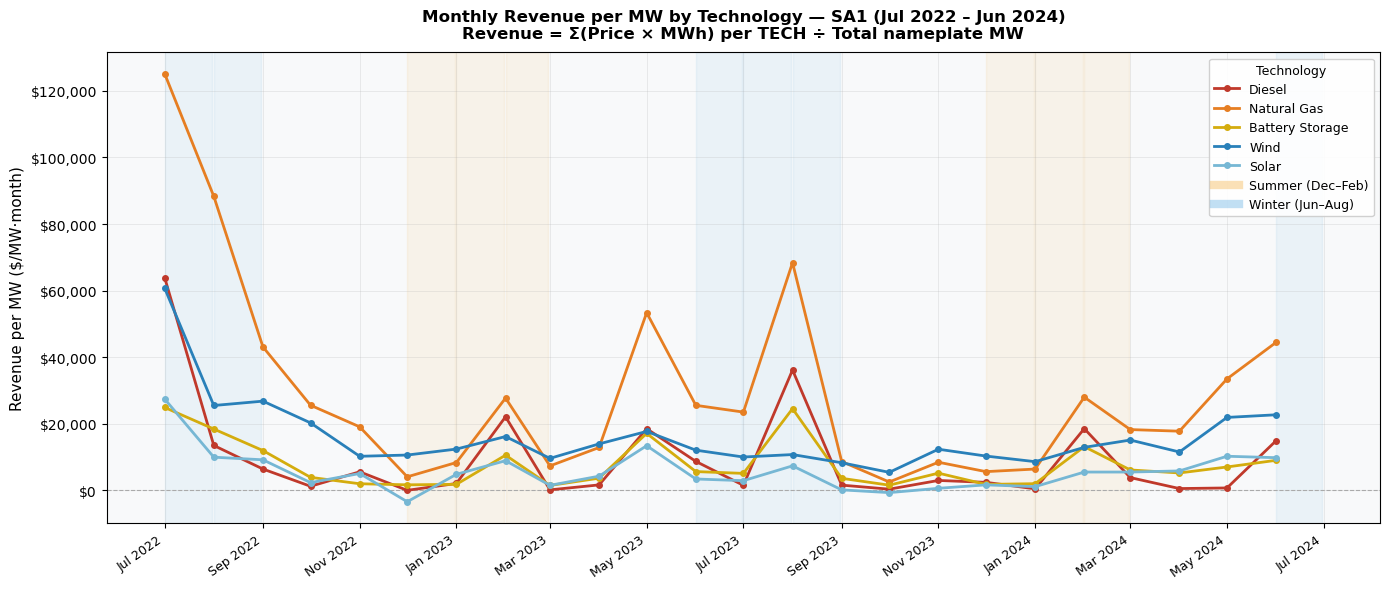

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.lines as mlines

# ── Monthly revenue per MW by technology ─────────────────────────────
# Revenue per MW = sum(revenue) / sum(nameplate_MW) for each TECH × month
gen = df_long.copy()
gen['month_start'] = gen.index.to_period('M').to_timestamp()
gen['revenue']     = gen['SA1_Price'] * gen['dispatch_MWh']

monthly_rev = (
    gen.groupby(['DUID', 'TECH', 'month_start'])['revenue']
    .sum()
    .reset_index()
)

# Merge nameplate from fix_nameplate
monthly_rev = monthly_rev.merge(
    fix_nameplate[['DUID', 'nameplate_MW']], on='DUID', how='inner'
)

# Aggregate to tech level: revenue per MW = total revenue / total nameplate
tech_monthly = (
    monthly_rev.groupby(['TECH', 'month_start'])
    .apply(lambda g: g['revenue'].sum() / g['nameplate_MW'].sum(), include_groups=False)
    .reset_index(name='rev_per_MW')
)

# ── Colour palette ────────────────────────────────────────────────────
COLORS = {
    'Diesel'          : '#c0392b',
    'Natural Gas'     : '#e67e22',
    'Battery Storage' : '#d4ac0d',
    'Wind'            : '#2980b9',
    'Solar'           : '#76b7d4',
}
TECH_ORDER = ['Diesel', 'Natural Gas', 'Battery Storage', 'Wind', 'Solar']

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for tech in TECH_ORDER:
    ts = tech_monthly[tech_monthly['TECH'] == tech].sort_values('month_start')
    if ts.empty:
        continue
    ax.plot(ts['month_start'], ts['rev_per_MW'],
            color=COLORS[tech], linewidth=2, marker='o',
            markersize=4, label=tech, zorder=4)

# Zero reference line
ax.axhline(0, color='#aaa', linewidth=0.8, linestyle='--', zorder=2)

# Seasonal shading (SH: Summer=Dec-Feb, Winter=Jun-Aug)
import pandas as pd
months = pd.date_range(tech_monthly['month_start'].min(),
                       tech_monthly['month_start'].max(), freq='MS')
for m in months:
    if m.month in [12, 1, 2]:
        ax.axvspan(m, m + pd.offsets.MonthEnd(1), color='#f39c12',
                   alpha=0.07, zorder=0)
    elif m.month in [6, 7, 8]:
        ax.axvspan(m, m + pd.offsets.MonthEnd(1), color='#3498db',
                   alpha=0.07, zorder=0)

# Formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))
ax.set_facecolor('#f8f9fa')
ax.grid(linewidth=0.4, alpha=0.4, zorder=0)
ax.set_ylabel('Revenue per MW ($/MW·month)', fontsize=11)
ax.set_xlabel('')

# Legend — tech lines + shading key
handles, labels = ax.get_legend_handles_labels()
handles += [
    mlines.Line2D([0],[0], color='#f39c12', linewidth=6, alpha=0.3, label='Summer (Dec–Feb)'),
    mlines.Line2D([0],[0], color='#3498db', linewidth=6, alpha=0.3, label='Winter (Jun–Aug)'),
]
ax.legend(handles=handles, fontsize=9, loc='upper right',
          title='Technology', title_fontsize=9, framealpha=0.9)

ax.set_title(
    'Monthly Revenue per MW by Technology — SA1 (Jul 2022 – Jun 2024)\n'
    'Revenue = Σ(Price × MWh) per TECH ÷ Total nameplate MW',
    fontsize=12, fontweight='bold', pad=10
)
plt.tight_layout()
plt.show()
